# S2 BACKTEST — BTC / GC / SI (Calendar-Spread Mean Reversion)

## Spec (exact)

### Calendar basis
$$
\mathrm{Cal}_t = \frac{F^{\mathrm{next}}_t - F^{\mathrm{near}}_t}{F^{\mathrm{near}}_t}
$$

### Signal
Rolling lookback $L = 126$ trading days:

$$
z_t = \frac{\mathrm{Cal}_t - \mu_L}{\sigma_L}
$$

where $\mu_L$ and $\sigma_L$ are the rolling mean and rolling standard deviation of $\mathrm{Cal}_t$ over the last $L$ trading days.


### Timing (spec)
- Signal is **observed** on day \(t\).
- Trades are **filled** on day \(t+1\) using **settlement** prices from the aligned panel.
- Forced close:
  - **Decision** made on day \(t\) when **near DTE < 7**.
  - **Execution/close** occurs on day \(t+1\).

> Repro note: to reproduce the older “same-day” behavior, set `fill_lag=0` in the backtest call.

## Roll handling / CID stability
- Positions are held by **CID** (contract ID `yyyymm`), not by rank column name (`GC1`, `GC2`, …).
- Each day, held CIDs are mapped back into that day’s rank columns (e.g., `GC1/GC2/GC3`).
- This prevents accidental exposure “teleporting” when rank columns roll.

## Execution & costs
- Integer contracts.
- Legs are **notional-neutral** (leg sizes chosen so near/next notionals match as closely as possible given integer rounding).
- Trading costs apply `tc_bps` (in bps) of **traded notional**, **per leg**.
$$
cost = tc_(bps) / 1e4 * |Δcontracts| * |price| * multiplier
$$

## Risk controls
- Maintenance-margin proxy with a utilization budget (with per-asset caps).
- Margin checked daily; forced liquidation if the budget is breached.
- Entry size is also clamped **after rounding** to satisfy the margin budget.

## IS / OOS split
- **In-sample (IS):** 2018–2023
- **Out-of-sample (OOS):** 2024–2025  
  (Split date controlled by `IS_END`.)


In [1]:

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple, Dict, Any, List

import numpy as np
import pandas as pd
import calendar
from datetime import date, timedelta


DATA_DIR = Path(".")
S2_START = pd.Timestamp("2018-01-01")

# GC/SI
xlsx_path_s2 = DATA_DIR / "Basis Data.xlsx"   

# BTC (spot + futures)
btc_xlsx_path = DATA_DIR / "IBIT.xlsx"        
SHEET_CONFIG = {
    "GC": ["XAU", "GC1", "GC2", "GC3"],
    "SI": ["XAG", "SI1", "SI2", "SI3"],
}


# helpers: Series extractions & building panels

In [2]:

S2_START = pd.Timestamp("2018-01-01")

xlsx_path_s2 = "Basis Data.xlsx"  
btc_xlsx_path = "IBIT.xlsx"        
SHEET_CONFIG = {
    "GC": ["XAU", "GC1", "GC2", "GC3"],
    "SI": ["XAG", "SI1", "SI2", "SI3"],
}

def extract_pair_as_series(df: pd.DataFrame, value_col_name: str, new_value_name: str | None = None) -> pd.Series:
    """Uses the column immediately to the LEFT as the date column """
    if new_value_name is None:
        new_value_name = value_col_name
    col_idx = df.columns.get_loc(value_col_name)
    date_col = df.columns[col_idx - 1]
    sub = df[[date_col, value_col_name]].copy().dropna()
    sub = sub.rename(columns={date_col: "date", value_col_name: new_value_name})
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.set_index("date").sort_index()
    sub = sub[~sub.index.duplicated(keep="last")]
    return sub[new_value_name]

def build_panel_for_sheet(sheet_name: str, tickers: list[str]) -> pd.DataFrame:
    df_raw = pd.read_excel(xlsx_path_s2, sheet_name=sheet_name)
    series_list = [extract_pair_as_series(df_raw, t, t) for t in tickers]
    panel = pd.concat(series_list, axis=1).sort_index()
    panel = panel.loc[panel.index >= S2_START]
    panel = panel.loc[:, ~panel.columns.duplicated(keep="first")]
    panel = panel[~panel.index.duplicated(keep="last")]
    return panel

def extract_series_btc(df: pd.DataFrame, date_col: str, value_col: str, value_name: str) -> pd.Series:
    sub = df[[date_col, value_col]].dropna()
    sub = sub.rename(columns={date_col: "date", value_col: value_name})
    sub["date"] = pd.to_datetime(sub["date"])
    sub = sub.set_index("date").sort_index()
    sub = sub[~sub.index.duplicated(keep="last")]
    return sub[value_name]


# helpers based off contract details; cid for tracking

In [3]:
def keep_mon_fri(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    return idx[idx.weekday < 5]

def third_last_business_day(year: int, month: int) -> date:
    last_day = calendar.monthrange(year, month)[1]
    all_days = [date(year, month, d) for d in range(1, last_day + 1)]
    biz_days = [d for d in all_days if d.weekday() < 5]
    return biz_days[-3]

def last_friday(year: int, month: int) -> date:
    last_day = calendar.monthrange(year, month)[1]
    d = date(year, month, last_day)
    while d.weekday() != 4:
        d -= timedelta(days=1)
    return d

def cid_yyyymm(y: int, m: int) -> int:
    return y * 100 + m

def cid_to_ym(cid: int) -> Tuple[int, int]:
    y = int(cid) // 100
    m = int(cid) % 100
    return y, m


In [4]:
def generate_gold_contract_months(trade_date: date, n_contracts: int = 3):
    allowed_months = [2, 4, 6, 8, 10, 12]
    result = []
    y, m = trade_date.year, trade_date.month
    while len(result) < n_contracts:
        if m in allowed_months:
            exp = third_last_business_day(y, m)
            if exp >= trade_date or len(result) > 0:
                result.append((y, m, exp))
        m += 1
        if m > 12:
            m = 1
            y += 1
    return result

def generate_silver_contract_months(trade_date: date, n_contracts: int = 3):
    # we changed the data for silver;
    result = []
    y, m = trade_date.year, trade_date.month
    while True:
        exp0 = third_last_business_day(y, m)
        if exp0 >= trade_date:
            break
        m += 1
        if m > 12:
            m = 1
            y += 1
    for k in range(n_contracts):
        mm = m + k
        yy = y + (mm - 1) // 12
        mm = ((mm - 1) % 12) + 1
        exp = third_last_business_day(yy, mm)
        result.append((yy, mm, exp))
    return result

def generate_btc_contract_months(trade_date: date, n_contracts: int = 3):
    result = []
    y, m = trade_date.year, trade_date.month
    this_exp = last_friday(y, m)

    if this_exp >= trade_date:
        cur_y, cur_m = y, m
    else:
        cur_m = m + 1
        cur_y = y
        if cur_m > 12:
            cur_m = 1
            cur_y += 1

    y, m = cur_y, cur_m
    while len(result) < n_contracts:
        exp = last_friday(y, m)
        result.append((y, m, exp))
        m += 1
        if m > 12:
            m = 1
            y += 1
    return result

def build_cid_and_dte_panels(
    index: pd.DatetimeIndex,
    rank_cols: list[str],
    gen_months_fn,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    cid_df = pd.DataFrame(index=index, columns=[f"{c}_CID" for c in rank_cols], dtype="Int64")
    dte_df = pd.DataFrame(index=index, columns=[f"{c}_DTE" for c in rank_cols], dtype=float)

    for ts in index:
        td = ts.date()
        months = gen_months_fn(td, n_contracts=len(rank_cols))
        for c, (yy, mm, exp) in zip(rank_cols, months):
            cid_df.loc[ts, f"{c}_CID"] = cid_yyyymm(yy, mm)
            dte_df.loc[ts, f"{c}_DTE"] = max((exp - td).days, 0)
    return cid_df, dte_df


# Here we build the sginal, spread sets, and costings

def compute_calendar_signal(panel: pd.DataFrame, near_col: str, far_col: str, L: int, min_periods: int) -> pd.DataFrame:
    out = pd.DataFrame(index=panel.index)
    F_near = panel[near_col].astype(float)
    F_far  = panel[far_col].astype(float)
    out["Cal"] = (F_far - F_near) / F_near
    mu = out["Cal"].rolling(L, min_periods=min_periods).mean()
    sd = out["Cal"].rolling(L, min_periods=min_periods).std()
    out["z"] = (out["Cal"] - mu) / sd
    out["z"] = out["z"].where(sd > 1e-12)
    return out

def build_spreads(fut_cols: Tuple[str, str, str], allow_skip: bool) -> list[Tuple[str, str]]:
    F1, F2, F3 = fut_cols
    spreads = [(F1, F2), (F2, F3)]
    if allow_skip:
        spreads.append((F1, F3))
    return spreads

def size_calendar_notional_neutral(
    target_notional_usd: float,
    px_near: float,
    px_far: float,
    mult: float,
    min_contracts: int = 1
) -> Tuple[int, int]:
    if not np.isfinite(px_near) or not np.isfinite(px_far) or px_near <= 0 or px_far <= 0:
        return (0, 0)

    n_near = max(int(round(target_notional_usd / (px_near * mult))), min_contracts)
    n_far0 = max(int(round(n_near * (px_near / px_far))), min_contracts)

    best, best_err = None, np.inf
    for k in (-1, 0, 1):
        n_far = max(min_contracts, n_far0 + k)
        err = abs(n_near * px_near * mult - n_far * px_far * mult)
        if err < best_err:
            best_err = err
            best = (n_near, n_far)
    return best if best is not None else (0, 0)

def fut_leg_trade_cost_bps_usd(d_contracts: int, px_fill: float, mult: float, tc_bps: float) -> float:
    """tc_bps of traded notional, per leg, only on trade days."""
    if d_contracts == 0 or (not np.isfinite(px_fill)):
        return 0.0
    tc_rate = tc_bps / 1e4
    traded_notional = abs(d_contracts) * abs(px_fill) * mult
    return tc_rate * traded_notional


# here it is setting up the OOP classes for margin proxy and budgeting and other areas

@dataclass(frozen=True)
class S2AssetSpec:
    name: str
    fut_cols: Tuple[str, str, str]
    multiplier: float
    tick_size: float
    maint_margin_rate: float = 0.10

    # Margin utilisation cap for each backtest
    margin_utilization_cap: Optional[float] = None

@dataclass(frozen=True)
class S2Params:
    lookback_L: int = 126
    min_periods: int = 63
    entry_z: float = 1.6
    exit_z: float = 0.2 
    force_close_dte_lt: int = 7
    tc_bps: float = 0.25
    allow_skip_spreads: bool = False
    # "extreme_abs"|"richest"|"poorest"|"side_extreme" - we set it up so we can choose what we want to maximise
    selection_mode: str = "extreme_abs"  

    mr_flip: bool = True   

    entry_min_dte_buffer: int = 0

    use_margin_sizing: bool = True

    # "How much of equity can be tied up in maintenance margin - 0.7 means 70% of equity, for intance in this case"
    margin_utilization: float = 0.70

    # Extra cushion. 0.85 means you only allow 85% of the utilization budget.
    margin_call_buffer: float = 0.85



# Stitching logic - wit hthe cid-to-rank utilities, which is the roll-sticking core

In [5]:
def _col_for_cid(
    cid_row: pd.Series,
    cid: int,
    fut_cols: Tuple[str, str, str],
) -> Optional[str]:
    """
    Given one day's CID row (e.g. GC1_CID, GC2_CID, GC3_CID),
    return which rank column currently holds `cid`.
    """
    for c in fut_cols:
        v = cid_row.get(f"{c}_CID")
        if pd.isna(v):
            continue
        if int(v) == int(cid):
            return c
    return None


def _dte_for_cid(
    cid_row: pd.Series,
    dte_row: pd.Series,
    cid: int,
    fut_cols: Tuple[str, str, str],
) -> float:
    c = _col_for_cid(cid_row, cid, fut_cols)
    if c is None:
        return np.nan
    return float(dte_row.get(f"{c}_DTE"))


def _spread_label_for_cids(
    cid_row: pd.Series,
    near_cid: int,
    far_cid: int,
    fut_cols: Tuple[str, str, str],
) -> str:
    """
    Reporting label only. If the held CIDs roll from GC1/GC2 to GC2/GC3,
    this label changes, but the exposure does not.
    """
    nc = _col_for_cid(cid_row, near_cid, fut_cols)
    fc = _col_for_cid(cid_row, far_cid, fut_cols)
    if nc is None or fc is None:
        return "UNMAPPED"
    return f"{nc}/{fc}"


def gross_notional_usd(
    pos_near: int,
    pos_far: int,
    px_near: float,
    px_far: float,
    mult: float,
) -> float:
    if not (np.isfinite(px_near) and np.isfinite(px_far)):
        return 0.0
    return (abs(pos_near) * abs(px_near) + abs(pos_far) * abs(px_far)) * mult


def margin_required_usd(gross_notional: float, maint_margin_rate: float) -> float:
    if not np.isfinite(gross_notional) or gross_notional <= 0:
        return 0.0
    return gross_notional * float(maint_margin_rate)


def effective_margin_util(params: "S2Params", spec: "S2AssetSpec") -> float:
    if spec.margin_utilization_cap is None:
        return float(params.margin_utilization)
    return float(min(params.margin_utilization, spec.margin_utilization_cap))


def margin_budget_usd(equity: float, params: "S2Params", spec: "S2AssetSpec") -> float:
    util = effective_margin_util(params, spec)
    return float(max(0.0, equity) * util * params.margin_call_buffer)


def clamp_targets_to_margin(
    tgt_near: int,
    tgt_far: int,
    px_near: float,
    px_far: float,
    spec: "S2AssetSpec",
    max_mreq: float,
) -> Tuple[int, int]:
    """
    Scales integer targets down so that maintenance margin <= max_mreq.
    Returns (0,0) if even the smallest feasible position would breach budget.
    """
    if tgt_near == 0 and tgt_far == 0:
        return 0, 0
    if not (np.isfinite(px_near) and np.isfinite(px_far)) or px_near <= 0 or px_far <= 0:
        return 0, 0

    gnot = (abs(tgt_near) * abs(px_near) + abs(tgt_far) * abs(px_far)) * spec.multiplier
    mreq = gnot * spec.maint_margin_rate

    if (not np.isfinite(mreq)) or (mreq <= max_mreq):
        return int(tgt_near), int(tgt_far)
    if mreq <= 0:
        return 0, 0

    scale = max_mreq / mreq

    new_near = int(np.sign(tgt_near) * np.floor(abs(tgt_near) * scale))
    new_far  = int(np.sign(tgt_far)  * np.floor(abs(tgt_far)  * scale))

    if new_near == 0 or new_far == 0:
        return 0, 0

    return new_near, new_far


#  Entry decision block - based off the spread:

In [6]:
def choose_spread_for_entry(
    spreads: list[Tuple[str, str]],
    px: pd.DataFrame,
    dte_rank: pd.DataFrame,
    sig: Dict[Tuple[str, str], pd.DataFrame],
    t: pd.Timestamp,
    params: S2Params
):
    rows = []
    for sp in spreads:
        near, far = sp

        if pd.isna(px.loc[t, near]) or pd.isna(px.loc[t, far]):
            continue

        z = sig[sp].loc[t, "z"]
        if not np.isfinite(z):
            continue

        near_dte_fill = float(dte_rank.loc[t, f"{near}_DTE"])
        min_entry_dte = params.force_close_dte_lt + params.entry_min_dte_buffer
        if (not np.isfinite(near_dte_fill)) or (near_dte_fill < min_entry_dte):
            continue

        rows.append((sp, float(z), float(near_dte_fill)))

    if not rows:
        return None, np.nan, None

    zvals = np.array([r[1] for r in rows], dtype=float)
    absz = np.abs(zvals)
    order_abs = np.argsort(-absz)
    rank_abs = {rows[idx][0]: int(j + 1) for j, idx in enumerate(order_abs)}

    mode = params.selection_mode
    if mode == "extreme_abs":
        best = rows[int(order_abs[0])][0]
    elif mode == "richest":
        best = rows[int(np.argmax(zvals))][0]
    elif mode == "poorest":
        best = rows[int(np.argmin(zvals))][0]
    elif mode == "side_extreme":
        pos = [(sp, z, d) for (sp, z, d) in rows if z >= params.entry_z]
        neg = [(sp, z, d) for (sp, z, d) in rows if z <= -params.entry_z]
        if pos:
            best = max(pos, key=lambda x: x[1])[0]
        elif neg:
            best = min(neg, key=lambda x: x[1])[0]
        else:
            return None, np.nan, None
    else:
        raise ValueError(f"Unknown selection_mode: {mode}")

    best_z = dict((sp, z) for sp, z, _ in rows)[best]
    info = {"rank_abs": rank_abs[best], "n_candidates": len(rows), "selection_mode": mode}
    return best, best_z, info


In [7]:
def backtest_s2_calendar_zmr_cidstable(
    asset: str,
    fut_panel: pd.DataFrame,
    cid_rank: pd.DataFrame,
    dte_rank: pd.DataFrame,
    spec: S2AssetSpec,
    target_notional_usd: float,
    params: S2Params = S2Params(),
    initial_equity: float = 1_000_000.0,
) -> dict:
    """
    Decide which rank spread to trade on decision day t.
    This chooses among candidate spreads that:
      - have valid prices
      - have a finite z
      - satisfy a minimum DTE at decision time (near DTE must be >= threshold)
    """

    idx = fut_panel.index.intersection(cid_rank.index).intersection(dte_rank.index).sort_values()
    idx = idx[idx.weekday < 5]

    px = fut_panel.loc[idx, list(spec.fut_cols)].astype(float).copy()
    cid_rank = cid_rank.loc[idx].copy()
    dte_rank = dte_rank.loc[idx].copy()

    spreads = build_spreads(spec.fut_cols, params.allow_skip_spreads)
    sig = {sp: compute_calendar_signal(px, sp[0], sp[1], params.lookback_L, params.min_periods) for sp in spreads}

    held_near_cid: Optional[int] = None
    held_far_cid: Optional[int] = None
    held_entry_sign: Optional[int] = None
    pos_near: int = 0
    pos_far: int = 0
    equity = float(initial_equity)

    daily_rows: List[Dict[str, Any]] = []
    trade_rows: List[Dict[str, Any]] = []
    dates = px.index

    if len(dates) < 2:
        raise ValueError("Need >= 2 dates.")

    for i in range(1, len(dates)):
        t = dates[i]
        t_prev = dates[i - 1]

        # MTM from t_prev -> t using the SAME HELD CIDs
        pnl_mtm = 0.0
        if (held_near_cid is not None) and (held_far_cid is not None) and (pos_near != 0 or pos_far != 0):
            row_prev = cid_rank.loc[t_prev]
            row_now  = cid_rank.loc[t]

            near_col_prev = _col_for_cid(row_prev, held_near_cid, spec.fut_cols)
            far_col_prev  = _col_for_cid(row_prev, held_far_cid,  spec.fut_cols)
            near_col_now  = _col_for_cid(row_now,  held_near_cid, spec.fut_cols)
            far_col_now   = _col_for_cid(row_now,  held_far_cid,  spec.fut_cols)

            if (near_col_prev is not None and far_col_prev is not None and near_col_now is not None and far_col_now is not None):
                pn_prev = float(px.loc[t_prev, near_col_prev])
                pf_prev = float(px.loc[t_prev, far_col_prev])
                pn_now  = float(px.loc[t, near_col_now])
                pf_now  = float(px.loc[t, far_col_now])

                if np.isfinite(pn_prev) and np.isfinite(pn_now):
                    pnl_mtm += (pn_now - pn_prev) * spec.multiplier * pos_near
                if np.isfinite(pf_prev) and np.isfinite(pf_now):
                    pnl_mtm += (pf_now - pf_prev) * spec.multiplier * pos_far

        equity += pnl_mtm

        # Same-day decisions + same-day fills at t
        cost_today = 0.0
        cid_row_t = cid_rank.loc[t]
        dte_row_t = dte_rank.loc[t]

        flat = (pos_near == 0 and pos_far == 0)

        # If in position but can't map held CIDs today -> force flat today
        if (not flat) and (held_near_cid is not None) and (held_far_cid is not None):
            near_col_t = _col_for_cid(cid_row_t, held_near_cid, spec.fut_cols)
            far_col_t  = _col_for_cid(cid_row_t, held_far_cid,  spec.fut_cols)

            if near_col_t is None or far_col_t is None:
                d_near = -pos_near
                d_far  = -pos_far

                px_near_fill = float(px.loc[t, near_col_t]) if near_col_t is not None else np.nan
                px_far_fill  = float(px.loc[t, far_col_t])  if far_col_t  is not None else np.nan

                if np.isfinite(px_near_fill):
                    cost_today += fut_leg_trade_cost_bps_usd(d_near, px_near_fill, spec.multiplier, params.tc_bps)
                if np.isfinite(px_far_fill):
                    cost_today += fut_leg_trade_cost_bps_usd(d_far,  px_far_fill,  spec.multiplier, params.tc_bps)

                equity -= cost_today

                pos_near, pos_far = 0, 0
                held_near_cid = None
                held_far_cid = None
                held_entry_sign = None

                trade_rows.append({
                    "date": t, "asset": asset,
                    "spread": "FLAT",
                    "near_cid": None, "far_cid": None,
                    "reason": "unmapped_cid_force_flat",
                    "d_near": d_near, "d_far": d_far,
                    "pos_near": 0, "pos_far": 0,
                    "cost_usd": cost_today,
                    "z_signal": np.nan,
                    "rank_abs": np.nan,
                    "n_candidates": np.nan,
                    "selection_mode": None,
                })

        flat = (pos_near == 0 and pos_far == 0)

        #  If in position: check exit (forced close or cross 0) and flatten today
        if (not flat) and (held_near_cid is not None) and (held_far_cid is not None):
            near_col_t = _col_for_cid(cid_row_t, held_near_cid, spec.fut_cols)
            far_col_t  = _col_for_cid(cid_row_t, held_far_cid,  spec.fut_cols)

            z_t = np.nan
            if near_col_t is not None and far_col_t is not None:
                sp = (near_col_t, far_col_t)
                if sp in sig and t in sig[sp].index:
                    z_t = float(sig[sp].loc[t, "z"])

            dte_t = _dte_for_cid(cid_row_t, dte_row_t, held_near_cid, spec.fut_cols)
            forced_close = (np.isfinite(dte_t) and dte_t < params.force_close_dte_lt)
            z_cross_exit = (held_entry_sign is not None and np.isfinite(z_t) and (z_t * held_entry_sign <= 0.0))

            if forced_close or z_cross_exit:
                reason = "forced_close_dte" if forced_close else "exit_cross_0"

                d_near = -pos_near
                d_far  = -pos_far

                px_near_fill = float(px.loc[t, near_col_t]) if near_col_t is not None else np.nan
                px_far_fill  = float(px.loc[t, far_col_t])  if far_col_t  is not None else np.nan

                exit_cost = 0.0
                if np.isfinite(px_near_fill):
                    exit_cost += fut_leg_trade_cost_bps_usd(d_near, px_near_fill, spec.multiplier, params.tc_bps)
                if np.isfinite(px_far_fill):
                    exit_cost += fut_leg_trade_cost_bps_usd(d_far,  px_far_fill,  spec.multiplier, params.tc_bps)

                cost_today += exit_cost
                equity -= exit_cost

                pos_near, pos_far = 0, 0
                held_near_cid = None
                held_far_cid = None
                held_entry_sign = None

                trade_rows.append({
                    "date": t, "asset": asset,
                    "spread": "FLAT",
                    "near_cid": None, "far_cid": None,
                    "reason": reason,
                    "d_near": d_near, "d_far": d_far,
                    "pos_near": 0, "pos_far": 0,
                    "cost_usd": exit_cost,
                    "z_signal": z_t,
                    "rank_abs": np.nan,
                    "n_candidates": np.nan,
                    "selection_mode": None,
                })

        flat = (pos_near == 0 and pos_far == 0)

        # If flat: select spread and enter today
        if flat:
            best_sp, best_z, info = choose_spread_for_entry(
                spreads=spreads, px=px, dte_rank=dte_rank, sig=sig, t=t, params=params
            )

            if best_sp is not None and np.isfinite(best_z):
                enter_ok = (params.selection_mode == "side_extreme") or (abs(best_z) >= params.entry_z)
                if enter_ok:
                    near_rank, far_rank = best_sp

                    near_cid = int(cid_row_t[f"{near_rank}_CID"])
                    far_cid  = int(cid_row_t[f"{far_rank}_CID"])

                    px_near_t = float(px.loc[t, near_rank])
                    px_far_t  = float(px.loc[t, far_rank])

                    # margin budget for THIS ASSET
                    max_mreq = margin_budget_usd(equity, params, spec)

                    if params.use_margin_sizing:
                        # gross notional budget implied by maint margin proxy
                        gross_notional_budget = max_mreq / max(spec.maint_margin_rate, 1e-12)
                        leg_notional = 0.5 * gross_notional_budget
                    else:
                        leg_notional = float(target_notional_usd)

                    n_abs, f_abs = size_calendar_notional_neutral(
                        leg_notional,
                        px_near_t,
                        px_far_t,
                        spec.multiplier
                    )

                    if params.mr_flip:
                        if best_z > 0:
                            tgt_near, tgt_far, reason, entry_sign = +n_abs, -f_abs, "entry_z_high", +1
                        else:
                            tgt_near, tgt_far, reason, entry_sign = -n_abs, +f_abs, "entry_z_low",  -1
                    else:
                        if best_z > 0:
                            tgt_near, tgt_far, reason, entry_sign = -n_abs, +f_abs, "entry_z_high", +1
                        else:
                            tgt_near, tgt_far, reason, entry_sign = +n_abs, -f_abs, "entry_z_low",  -1

                    tgt_near, tgt_far = clamp_targets_to_margin(
                        tgt_near=tgt_near,
                        tgt_far=tgt_far,
                        px_near=px_near_t,
                        px_far=px_far_t,
                        spec=spec,
                        max_mreq=max_mreq,
                    )

                    # if we cannot afford even 1x1 responsibly, skip entry
                    if tgt_near == 0 or tgt_far == 0:
                        pass
                    else:
                        d_near = tgt_near - pos_near
                        d_far  = tgt_far  - pos_far

                        px_near_fill = float(px.loc[t, near_rank])
                        px_far_fill  = float(px.loc[t, far_rank])

                        entry_cost = 0.0
                        entry_cost += fut_leg_trade_cost_bps_usd(d_near, px_near_fill, spec.multiplier, params.tc_bps)
                        entry_cost += fut_leg_trade_cost_bps_usd(d_far,  px_far_fill,  spec.multiplier, params.tc_bps)

                        equity -= entry_cost
                        cost_today += entry_cost

                        held_near_cid = near_cid
                        held_far_cid  = far_cid
                        held_entry_sign = entry_sign
                        pos_near, pos_far = tgt_near, tgt_far

                        spread_lbl = _spread_label_for_cids(cid_row_t, near_cid, far_cid, spec.fut_cols)

                        trade_rows.append({
                            "date": t, "asset": asset,
                            "spread": spread_lbl,
                            "near_cid": int(near_cid),
                            "far_cid":  int(far_cid),
                            "reason": reason,
                            "d_near": d_near, "d_far": d_far,
                            "pos_near": pos_near, "pos_far": pos_far,
                            "cost_usd": entry_cost,
                            "z_signal": float(best_z),
                            "rank_abs": info["rank_abs"],
                            "n_candidates": info["n_candidates"],
                            "selection_mode": info["selection_mode"],
                        })

        # Margin-call check + daily log - will literally never be used, but just to make it
        gnot = 0.0
        mreq = 0.0
        mutil = np.nan

        cid_row_t = cid_rank.loc[t]

        if held_near_cid is None or held_far_cid is None or (pos_near == 0 and pos_far == 0):
            spread_lbl = "FLAT"
            near_cid_v, far_cid_v = None, None
        else:
            spread_lbl = _spread_label_for_cids(cid_row_t, held_near_cid, held_far_cid, spec.fut_cols)
            near_cid_v, far_cid_v = int(held_near_cid), int(held_far_cid)

            near_col_t2 = _col_for_cid(cid_row_t, held_near_cid, spec.fut_cols)
            far_col_t2  = _col_for_cid(cid_row_t, held_far_cid,  spec.fut_cols)

            if near_col_t2 is not None and far_col_t2 is not None:
                px_near_map = float(px.loc[t, near_col_t2])
                px_far_map  = float(px.loc[t, far_col_t2])
                gnot = gross_notional_usd(pos_near, pos_far, px_near_map, px_far_map, spec.multiplier)
                mreq = margin_required_usd(gnot, spec.maint_margin_rate)

            max_mreq = margin_budget_usd(equity, params, spec)
            mutil = (mreq / equity) if (equity > 0 and np.isfinite(mreq)) else np.nan

            if np.isfinite(mreq) and (mreq > max_mreq) and (near_col_t2 is not None and far_col_t2 is not None):
                d_near = -pos_near
                d_far  = -pos_far

                px_near_fill = float(px.loc[t, near_col_t2])
                px_far_fill  = float(px.loc[t, far_col_t2])

                mc_cost = 0.0
                mc_cost += fut_leg_trade_cost_bps_usd(d_near, px_near_fill, spec.multiplier, params.tc_bps)
                mc_cost += fut_leg_trade_cost_bps_usd(d_far,  px_far_fill,  spec.multiplier, params.tc_bps)

                equity -= mc_cost
                cost_today += mc_cost

                pos_near, pos_far = 0, 0
                held_near_cid = None
                held_far_cid = None
                held_entry_sign = None

                trade_rows.append({
                    "date": t, "asset": asset,
                    "spread": "FLAT",
                    "near_cid": None, "far_cid": None,
                    "reason": "margin_call_force_flat",
                    "d_near": d_near, "d_far": d_far,
                    "pos_near": 0, "pos_far": 0,
                    "cost_usd": mc_cost,
                    "z_signal": np.nan,
                    "rank_abs": np.nan,
                    "n_candidates": np.nan,
                    "selection_mode": None,
                })

                spread_lbl = "FLAT"
                near_cid_v, far_cid_v = None, None
                gnot = 0.0
                mreq = 0.0
                mutil = np.nan

        daily_rows.append({
            "date": t,
            "equity": equity,
            "pnl_mtm_usd": pnl_mtm,
            "cost_usd": cost_today,
            "pos_near": pos_near,
            "pos_far": pos_far,
            "spread": spread_lbl,
            "near_cid": near_cid_v,
            "far_cid": far_cid_v,
            "gross_notional_usd": gnot,
            "maint_margin_req_usd": mreq,
            "margin_util": mutil,
        })

    daily = pd.DataFrame(daily_rows).set_index("date").sort_index()
    daily["ret"] = daily["equity"].pct_change().fillna(0.0)

    trades = pd.DataFrame(trade_rows)
    if not trades.empty:
        trades["date"] = pd.to_datetime(trades["date"])
        trades = trades.sort_values("date")

    return {
        "daily": daily,
        "trades": trades,
        "spec": spec,
        "params": params,
        "signals": sig,
        "spreads": spreads,
        "cid_rank": cid_rank,
        "dte_rank": dte_rank
    }


# setting up the IS & OOOS helpers

In [8]:
def split_is_oos(df: pd.DataFrame, is_end: str = "2023-12-31") -> Tuple[pd.DataFrame, pd.DataFrame]:
    is_end = pd.Timestamp(is_end)
    ins = df.loc[df.index <= is_end].copy()
    oos = df.loc[df.index > is_end].copy()
    return ins, oos

# -----------------------------
# Load panels
# -----------------------------
gc_panel = build_panel_for_sheet("GC", SHEET_CONFIG["GC"])
si_panel = build_panel_for_sheet("SI", SHEET_CONFIG["SI"])

btc_raw = pd.read_excel(btc_xlsx_path, sheet_name="BTC")
btc_series = [
    extract_series_btc(btc_raw, "Date-XBT",  "XBT-USD", "xbt_usd"),
    extract_series_btc(btc_raw, "Date-BTC1", "BTC1",    "btc1"),
    extract_series_btc(btc_raw, "Date-BTC2", "BTC2",    "btc2"),
    extract_series_btc(btc_raw, "Date-BTC3", "BTC3",    "btc3"),
]
btc_panel = pd.concat(btc_series, axis=1).sort_index()
btc_panel = btc_panel.loc[btc_panel.index >= S2_START]
btc_panel = btc_panel.loc[:, ~btc_panel.columns.duplicated(keep="first")]
btc_panel = btc_panel[~btc_panel.index.duplicated(keep="last")]

# GC/SI are business-day panels; keep Mon–Fri
gc_panel = gc_panel.loc[keep_mon_fri(gc_panel.index)]
si_panel = si_panel.loc[keep_mon_fri(si_panel.index)]

BTC trades: 219
GC  trades: 118
SI  trades: 183

[BTC] FIRST POSITION WINDOW (CID-stable, spread labels roll-down by rank)
               spread  near_cid   far_cid  pos_near  pos_far
date                                                        
2018-04-17  btc2/btc3  201805.0  201806.0       -48       48
2018-04-18       FLAT       NaN       NaN         0        0
2018-04-19       FLAT       NaN       NaN         0        0
2018-04-20       FLAT       NaN       NaN         0        0
2018-04-23       FLAT       NaN       NaN         0        0
2018-04-24       FLAT       NaN       NaN         0        0
2018-04-25       FLAT       NaN       NaN         0        0
2018-04-26       FLAT       NaN       NaN         0        0
2018-04-27       FLAT       NaN       NaN         0        0
2018-04-30       FLAT       NaN       NaN         0        0
2018-05-01       FLAT       NaN       NaN         0        0
2018-05-02       FLAT       NaN       NaN         0        0
2018-05-03       FLAT  

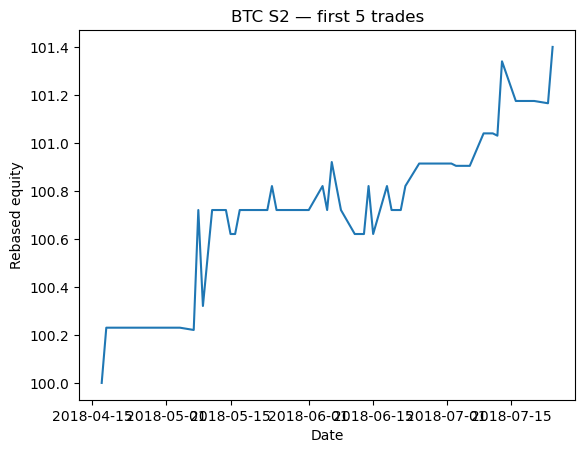

In [9]:
gc_cid, gc_dte   = build_cid_and_dte_panels(gc_panel.index,  ["GC1","GC2","GC3"],   generate_gold_contract_months)
si_cid, si_dte   = build_cid_and_dte_panels(si_panel.index,  ["SI1","SI2","SI3"],   generate_silver_contract_months)
btc_cid, btc_dte = build_cid_and_dte_panels(btc_panel.index, ["btc1","btc2","btc3"], generate_btc_contract_months)

BTC_SPEC = S2AssetSpec("BTC", ("btc1","btc2","btc3"), multiplier=5.0,    tick_size=5.0,   maint_margin_rate=0.20, margin_utilization_cap=0.90)
GC_SPEC  = S2AssetSpec("GC",  ("GC1","GC2","GC3"),   multiplier=100.0,  tick_size=0.1,   maint_margin_rate=0.05, margin_utilization_cap=0.35)
SI_SPEC  = S2AssetSpec("SI",  ("SI1","SI2","SI3"),   multiplier=5000.0, tick_size=0.005, maint_margin_rate=0.08, margin_utilization_cap=0.25)



params = S2Params(
    lookback_L=126,
    min_periods=63,
    entry_z=1.6,
    force_close_dte_lt=7,
    tc_bps=0.25,
    allow_skip_spreads=False,
    selection_mode="extreme_abs",

    mr_flip=True,
    use_margin_sizing=True,

    # global target; 
    margin_utilization=0.90,
    # Cash buffer default
    margin_call_buffer=0.85
)


TARGET_NOTIONAL = 2_000_000.0
INITIAL_EQUITY  = 1_000_000.0


btc_res = backtest_s2_calendar_zmr_cidstable("BTC", btc_panel[["btc1","btc2","btc3"]], btc_cid, btc_dte, BTC_SPEC, TARGET_NOTIONAL, params, INITIAL_EQUITY)
gc_res  = backtest_s2_calendar_zmr_cidstable("GC",  gc_panel[["GC1","GC2","GC3"]],    gc_cid,  gc_dte,  GC_SPEC,  TARGET_NOTIONAL, params, INITIAL_EQUITY)
si_res  = backtest_s2_calendar_zmr_cidstable("SI",  si_panel[["SI1","SI2","SI3"]],    si_cid,  si_dte,  SI_SPEC,  TARGET_NOTIONAL, params, INITIAL_EQUITY)

print("BTC trades:", len(btc_res["trades"]))
print("GC  trades:", len(gc_res["trades"]))
print("SI  trades:", len(si_res["trades"]))

# Run the first position, and see if rolling logic and everything else is correct
def first_position_window(res: dict, label: str, n: int = 30):
    d = res["daily"].copy()
    inpos = (d["pos_near"] != 0) | (d["pos_far"] != 0)
    if not inpos.any():
        print(f"\n[{label}] no positions.")
        return
    start = d.index[inpos][0]
    w = d.loc[start:].head(n)[["spread","near_cid","far_cid","pos_near","pos_far"]]
    print(f"\n[{label}] FIRST POSITION WINDOW (CID-stable, spread labels roll-down by rank)")
    print(w)

first_position_window(btc_res, "BTC", 35)
first_position_window(gc_res,  "GC",  35)
first_position_window(si_res,  "SI",  35)

# Plot: first 5 trades equity rebased to 100 - show that it works
import matplotlib.pyplot as plt

def plot_first_n_trades_rebased(res: dict, n_entries: int = 5, title: str = ""):
    daily = res["daily"].copy()
    tr = res["trades"].copy()

    if daily.empty:
        print("Daily is empty.")
        return
    if tr.empty:
        print("No trades.")
        return

    tr["date"] = pd.to_datetime(tr["date"])
    tr = tr.sort_values("date")

    tr["is_entry"] = tr["reason"].astype(str).str.startswith("entry")
    entries = tr[tr["is_entry"]].head(n_entries)
    if entries.empty:
        print("No entry trades found.")
        return

    exit_dates = []
    for ed in entries["date"]:
        after = tr[tr["date"] > ed]
        ex = after[(after["pos_near"] == 0) & (after["pos_far"] == 0)].head(1)
        exit_dates.append(ex["date"].iloc[0] if not ex.empty else daily.index[-1])

    start = pd.to_datetime(entries["date"].iloc[0])
    end   = pd.to_datetime(exit_dates[-1])

    window = daily.loc[(daily.index >= start) & (daily.index <= end)].copy()
    if window.empty:
        print("Empty window.")
        return

    window["equity_rebased_100"] = 100.0 * window["equity"] / window["equity"].iloc[0]

    # print only columns that exist
    desired = ["date","asset","spread","near_cid","far_cid","reason","z_signal","rank_abs","cost_usd"]
    have = [c for c in desired if c in entries.columns]
    print("\nFirst entries:")
    print(entries[have])

    print("\nExit dates for those entries:")
    print(list(zip(entries["date"].dt.date, pd.to_datetime(exit_dates).date)))

    plt.figure()
    plt.plot(window.index, window["equity_rebased_100"])
    plt.title(title or f"Equity (rebased to 100) — first {n_entries} trades")
    plt.xlabel("Date")
    plt.ylabel("Rebased equity")
    plt.show()

plot_first_n_trades_rebased(btc_res, n_entries=5, title="BTC S2 — first 5 trades")


In [10]:
def _infer_held_spread_on_day(res: dict, dt: pd.Timestamp) -> Tuple[Optional[str], Optional[str], Optional[float]]:
    daily = res["daily"]
    cid_rank = res["cid_rank"]
    sig = res["signals"]
    spec = res["spec"]  
    if dt not in daily.index:
        return None, None, None

    row = daily.loc[dt]
    if (row["pos_near"] == 0 and row["pos_far"] == 0) or pd.isna(row["near_cid"]) or pd.isna(row["far_cid"]):
        return None, None, None

    near_cid = int(row["near_cid"])
    far_cid  = int(row["far_cid"])
    cid_row  = cid_rank.loc[dt]

    # requires _col_for_cid to exist in scope
    near_rank = _col_for_cid(cid_row, near_cid, spec.fut_cols)
    far_rank  = _col_for_cid(cid_row, far_cid,  spec.fut_cols)
    if near_rank is None or far_rank is None:
        return near_rank, far_rank, None

    sp = (near_rank, far_rank)
    z_t = None
    if sp in sig and dt in sig[sp].index:
        z_t = float(sig[sp].loc[dt, "z"])
    return near_rank, far_rank, z_t


# More sanity checks, double checking the entire trade/s to verify logic.

In [11]:
def deep_dive_first_two_trades(res: dict, label: str, max_rows: int = 12):
    daily = res["daily"].copy()
    tr = res["trades"].copy()

    if daily.empty:
        print(f"\n[{label}] daily is empty.")
        return
    if tr.empty:
        print(f"\n[{label}] no trades.")
        return
    if "equity" not in daily.columns:
        print(f"\n[{label}] daily missing 'equity' col. Has: {list(daily.columns)}")
        return

    # ensure sorted index
    daily = daily.sort_index()

    tr["date"] = pd.to_datetime(tr["date"])
    tr = tr.sort_values("date")

    tr["is_entry"] = tr["reason"].astype(str).str.startswith("entry")
    entries = tr[tr["is_entry"]].head(2)
    if entries.empty:
        print(f"\n[{label}] no entries.")
        return

    print(f"\n================ {label} — FIRST 2 TRADES DEEP DIVE ================")

    for k, entry in enumerate(entries.itertuples(index=False), start=1):
        entry_dt = pd.to_datetime(entry.date)

        # align entry_dt to a valid daily date (same-day fill logic)
        if entry_dt not in daily.index:
            pos = daily.index.searchsorted(entry_dt)
            if pos >= len(daily.index):
                print(f"\n--- Trade {k} ---")
                print(f"Entry date {entry_dt.date()} beyond daily range.")
                continue
            entry_dt = daily.index[pos]

        # find exit trade date (first time positions go flat after entry)
        after = tr[tr["date"] > entry_dt]
        exit_row = after[(after["pos_near"] == 0) & (after["pos_far"] == 0)].head(1)
        exit_dt = pd.to_datetime(exit_row["date"].iloc[0]) if not exit_row.empty else daily.index[-1]

        # align exit_dt to daily
        if exit_dt not in daily.index:
            pos = daily.index.searchsorted(exit_dt)
            exit_dt = daily.index[min(pos, len(daily.index) - 1)]

        entry_pos = daily.index.get_loc(entry_dt)
        exit_pos  = daily.index.get_loc(exit_dt)

        start_pos = max(0, entry_pos - 2)
        end_pos   = max(start_pos, exit_pos)

        window = daily.iloc[start_pos:end_pos + 1].copy()

        print(f"\n--- Trade {k} ---")
        print(f"Entry fill date: {entry_dt.date()} | Exit fill date: {exit_dt.date()}")
        print(f"Entry spread(label): {getattr(entry,'spread',None)} | near_cid={getattr(entry,'near_cid',None)} far_cid={getattr(entry,'far_cid',None)}")
        print(f"Entry reason: {entry.reason} | z_signal(entry decision): {float(entry.z_signal):.6f}")
        print(f"Contracts after fill: pos_near={entry.pos_near} pos_far={entry.pos_far} | TC (fill): ${float(entry.cost_usd):,.2f}")

        rows = []
        for dt, r in window.iterrows():
            near_rank, far_rank, z_t = _infer_held_spread_on_day(res, dt)
            rows.append({
                "date": dt.date(),
                "equity": float(r["equity"]),
                "pnl_mtm": float(r.get("pnl_mtm_usd", np.nan)),
                "tcost": float(r.get("cost_usd", np.nan)),
                "pos_near": int(r.get("pos_near", 0)),
                "pos_far": int(r.get("pos_far", 0)),
                "spread_lbl": r.get("spread", None),
                "held_rank_spread": None if near_rank is None or far_rank is None else f"{near_rank}/{far_rank}",
                "z_held": z_t,
            })

        dbg = pd.DataFrame(rows)
        if dbg.empty:
            print("DBG is empty — no rows collected.")
            continue

        base = dbg["equity"].iloc[0]
        dbg["equity_rebased_100"] = 100.0 * dbg["equity"] / (base if np.isfinite(base) and base != 0 else 1.0)

        print("\nPath (first few rows):")
        print(dbg.head(max_rows).to_string(index=False))

        print("\nLast rows around exit:")
        print(dbg.tail(3).to_string(index=False))

deep_dive_first_two_trades(btc_res, "BTC")
deep_dive_first_two_trades(gc_res,  "GC")
deep_dive_first_two_trades(si_res,  "SI")




================ BTC — FIRST 2 TRADES DEEP DIVE ================

--- Trade 1 ---
Entry fill date: 2018-04-17 | Exit fill date: 2018-04-18
Entry spread(label): btc2/btc3 | near_cid=201805.0 far_cid=201806.0
Entry reason: entry_z_low | z_signal(entry decision): -1.754614
Contracts after fill: pos_near=-48 pos_far=48 | TC (fill): $94.59

Path (first few rows):
      date     equity  pnl_mtm  tcost  pos_near  pos_far spread_lbl held_rank_spread    z_held  equity_rebased_100
2018-04-13 1000000.00      0.0   0.00         0        0       FLAT             None       NaN          100.000000
2018-04-16 1000000.00      0.0   0.00         0        0       FLAT             None       NaN          100.000000
2018-04-17  999905.41      0.0  94.59       -48       48  btc2/btc3        btc2/btc3 -1.754614           99.990541
2018-04-18 1002207.88   2400.0  97.53         0        0       FLAT             None       NaN          100.220788

Last rows around exit:
      date     equity  pnl_mtm  tcost  

# MAIN BACKTESTING BLOCK

In [12]:
IS_END = pd.Timestamp("2023-12-31")

# Shared rules (IDENTICAL across BTC / GC / SI) for APPLES TO APPLES COMPARISON
COMMON_PARAMS = S2Params(
    lookback_L=126,
    min_periods=63,
    entry_z=1.6,
    exit_z=0.1, 
    force_close_dte_lt=10,
    tc_bps=0.15,

    allow_skip_spreads=False,
    selection_mode="extreme_abs",

    mr_flip=True,
    use_margin_sizing=False,          

    margin_utilization=0.95,
    margin_call_buffer=0.8,
)

btc_params = COMMON_PARAMS
gc_params  = COMMON_PARAMS
si_params  = COMMON_PARAMS

# Per-asset mechanics only (contract specs differ)

btc_params = S2Params(**{**COMMON_PARAMS.__dict__,
    "min_periods": 25,         
    "force_close_dte_lt": 3,    
})


btc_spec = S2AssetSpec(
    name="BTC",
    fut_cols=("btc1","btc2","btc3"),
    multiplier=5.0,
    tick_size=5.0,
    maint_margin_rate=0.18,
    margin_utilization_cap=1.0,
)

gc_spec = S2AssetSpec(
    name="GC",
    fut_cols=("GC1","GC2","GC3"),
    multiplier=100.0,
    tick_size=0.1,
    maint_margin_rate=0.05,
    margin_utilization_cap=1.0,
)

si_spec = S2AssetSpec(
    name="SI",
    fut_cols=("SI1","SI2","SI3"),
    multiplier=5000.0,
    tick_size=0.005,
    maint_margin_rate=0.08,
    margin_utilization_cap=0.75,
)


# Summary stats for table

In [13]:
def summarize_daily(d: pd.DataFrame) -> dict:
    if d is None or d.empty:
        return {"start_eq": np.nan, "final_eq": np.nan, "cum_ret": np.nan,
                "ann_ret": np.nan, "ann_vol": np.nan, "sharpe": np.nan, "max_dd": np.nan}

    eq = d["equity"].astype(float)
    rets = eq.pct_change().fillna(0.0)

    start_eq = float(eq.iloc[0])
    final_eq = float(eq.iloc[-1])
    cum_ret  = final_eq / start_eq - 1.0

    ann = 252.0
    ann_ret = (final_eq / start_eq) ** (ann / max(len(eq) - 1, 1)) - 1.0
    ann_vol = rets.std(ddof=0) * np.sqrt(ann)
    sharpe  = (rets.mean() / (rets.std(ddof=0) + 1e-12)) * np.sqrt(ann)
    max_dd  = float((eq / eq.cummax() - 1.0).min())

    return {
        "start_eq": start_eq,
        "final_eq": final_eq,
        "cum_ret":  float(cum_ret),
        "ann_ret":  float(ann_ret),
        "ann_vol":  float(ann_vol),
        "sharpe":   float(sharpe),
        "max_dd":   float(max_dd),
    }

def summarize_res_split(res: dict, label: str, is_end: pd.Timestamp = IS_END, tail: int = 8):
    daily = res["daily"].copy()
    trades = res["trades"].copy()

    # equity growth series
    daily["eq_rebased_100"] = 100.0 * daily["equity"] / float(daily["equity"].iloc[0])
    daily["cum_ret_series"] = daily["eq_rebased_100"] / 100.0 - 1.0

    # split
    is_d = daily.loc[daily.index <= is_end].copy()
    oos_d = daily.loc[daily.index > is_end].copy()

    s_full = summarize_daily(daily)
    s_is   = summarize_daily(is_d)
    s_oos  = summarize_daily(oos_d)

    # trade counts by split (trade df stores date as column)
    n_tr_full = len(trades) if trades is not None and not trades.empty else 0
    if trades is None or trades.empty:
        n_tr_is = 0
        n_tr_oos = 0
    else:
        tr = trades.copy()
        tr["date"] = pd.to_datetime(tr["date"])
        n_tr_is  = int((tr["date"] <= is_end).sum())
        n_tr_oos = int((tr["date"] >  is_end).sum())

    def _print_block(tag: str, s: dict, ntr: int):
        print(f"\n[{label}] {tag}")
        print(f"  Start eq: {s['start_eq']:,.2f} | End eq: {s['final_eq']:,.2f}")
        print(f"  Cum ret:  {s['cum_ret']*100:.2f}%")
        print(f"  Ann ret:  {s['ann_ret']*100:.2f}% | Ann vol: {s['ann_vol']*100:.2f}% | Sharpe: {s['sharpe']:.2f}")
        print(f"  Max DD:   {s['max_dd']*100:.2f}% | Trades: {ntr}")

    print(f"\n================ {label} — SUMMARY (IS_END={is_end.date()}) ================")
    _print_block("FULL", s_full, n_tr_full)
    _print_block("IS",   s_is,   n_tr_is)
    _print_block("OOS",  s_oos,  n_tr_oos)

    print(f"\n[{label}] Equity growth (rebased to 100) — last {tail} rows:")
    print(daily[["equity","eq_rebased_100","cum_ret_series"]].tail(tail).to_string())

    return {"daily": daily, "stats_full": s_full, "stats_is": s_is, "stats_oos": s_oos}


In [14]:
# Run backtests
btc_res = backtest_s2_calendar_zmr_cidstable(
    "BTC", btc_panel[["btc1","btc2","btc3"]], btc_cid, btc_dte,
    btc_spec, TARGET_NOTIONAL, btc_params, INITIAL_EQUITY
)

gc_res  = backtest_s2_calendar_zmr_cidstable(
    "GC", gc_panel[["GC1","GC2","GC3"]], gc_cid, gc_dte,
    gc_spec, TARGET_NOTIONAL, gc_params, INITIAL_EQUITY
)

si_res  = backtest_s2_calendar_zmr_cidstable(
    "SI", si_panel[["SI1","SI2","SI3"]], si_cid, si_dte,
    si_spec, TARGET_NOTIONAL, si_params, INITIAL_EQUITY
)

# -----------------------------
# Print clean summary stats + equity growth
# -----------------------------
btc_sum = summarize_res_split(btc_res, "BTC (baseline)")
gc_sum  = summarize_res_split(gc_res,  "GC (bayes)")
si_sum  = summarize_res_split(si_res,  "SI (bayes)")



================ BTC (baseline) — SUMMARY (IS_END=2023-12-31) ================

[BTC (baseline)] FULL
  Start eq: 1,000,000.00 | End eq: 1,195,731.06
  Cum ret:  19.57%
  Ann ret:  2.25% | Ann vol: 2.61% | Sharpe: 0.86
  Max DD:   -2.86% | Trades: 153

[BTC (baseline)] IS
  Start eq: 1,000,000.00 | End eq: 1,164,768.12
  Cum ret:  16.48%
  Ann ret:  2.49% | Ann vol: 2.90% | Sharpe: 0.86
  Max DD:   -2.86% | Trades: 135

[BTC (baseline)] OOS
  Start eq: 1,164,768.12 | End eq: 1,195,731.06
  Cum ret:  2.66%
  Ann ret:  1.44% | Ann vol: 1.19% | Sharpe: 1.20
  Max DD:   -0.91% | Trades: 18

[BTC (baseline)] Equity growth (rebased to 100) — last 8 rows:
                  equity  eq_rebased_100  cum_ret_series
date                                                    
2025-10-01  1.196538e+06      119.653837        0.196538
2025-10-02  1.196538e+06      119.653837        0.196538
2025-10-03  1.196538e+06      119.653837        0.196538
2025-10-06  1.196481e+06      119.648106        0.196481


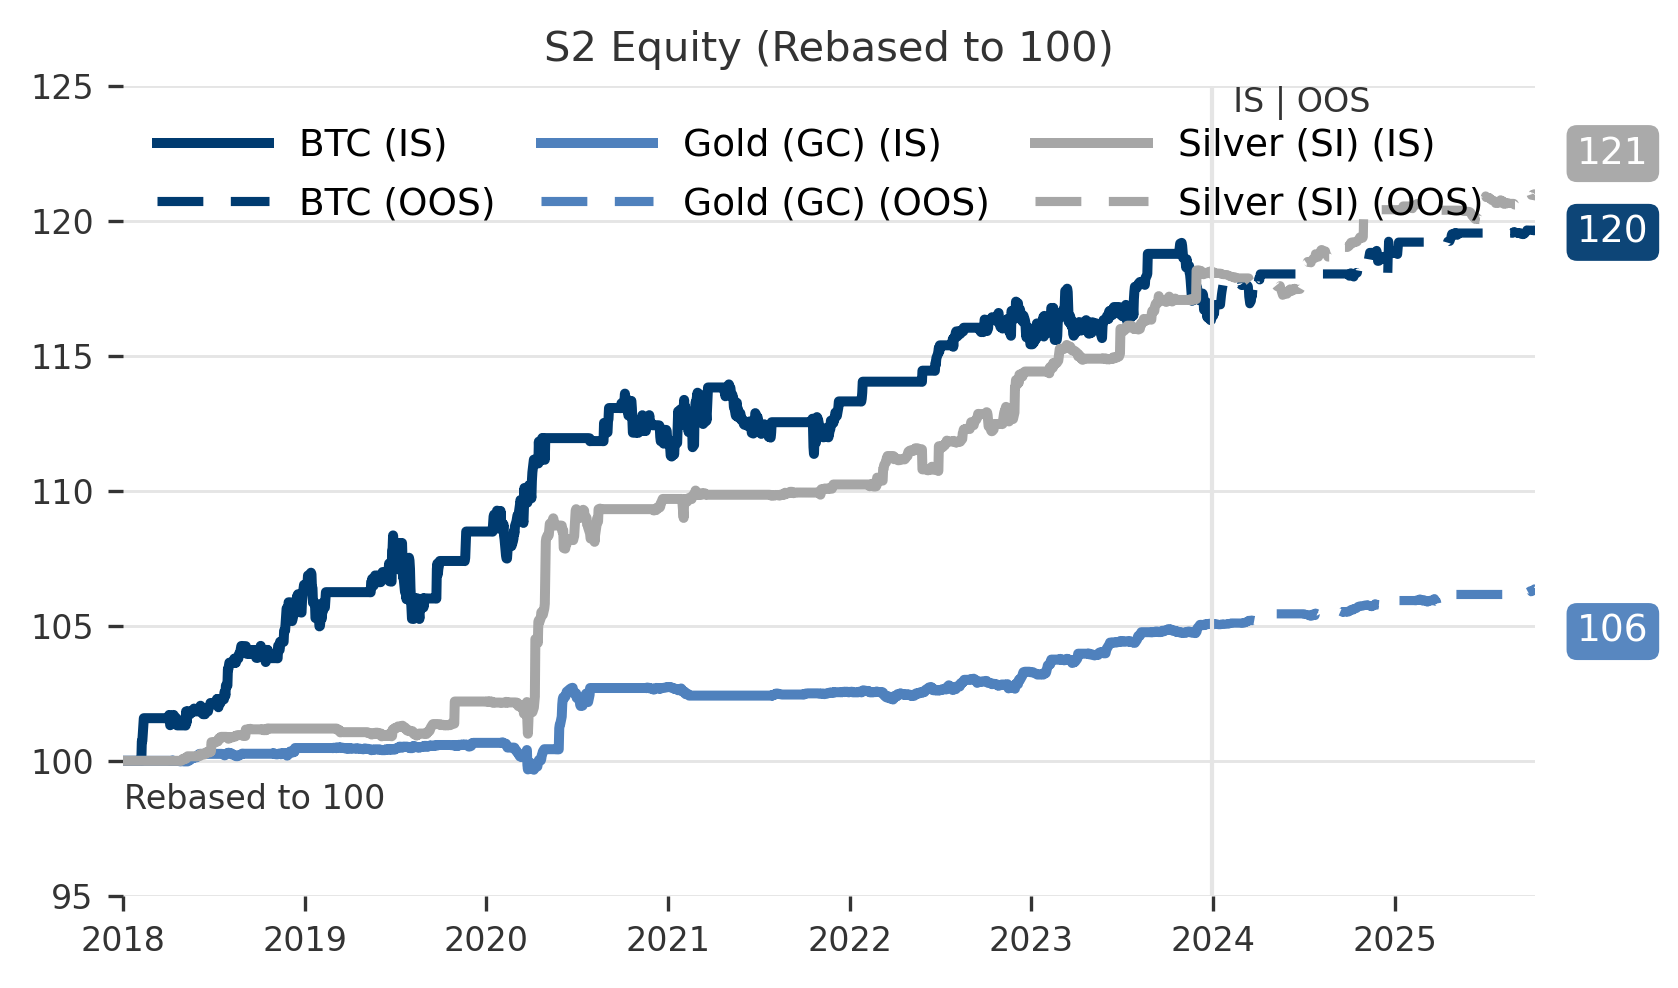

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_s2_equity_curves_is_oos_compact(
    btc_res, gc_res, si_res,
    is_end="2023-12-31",
    title="S2 Equity (Rebased to 100)",
    out_pdf="s2_equity_rebased_100_is_oos_compact.pdf",
    out_png="s2_equity_rebased_100_is_oos_compact.png",
    figsize=(5.09, 3.75),
    y_min_fixed=95.0,
    y_grid_step=5.0,
    add_end_bubbles=True,          
):
    is_end = pd.Timestamp(is_end)

    eq_btc_raw = btc_res["daily"]["equity"].dropna().astype(float)
    eq_gc_raw  = gc_res["daily"]["equity"].dropna().astype(float)
    eq_si_raw  = si_res["daily"]["equity"].dropna().astype(float)

    common_index = (
        eq_btc_raw.index
        .intersection(eq_gc_raw.index)
        .intersection(eq_si_raw.index)
    ).sort_values()

    eq_btc = eq_btc_raw.reindex(common_index)
    eq_gc  = eq_gc_raw.reindex(common_index)
    eq_si  = eq_si_raw.reindex(common_index)

    base_date = common_index[0]
    btc_idx = eq_btc / float(eq_btc.loc[base_date]) * 100.0
    gc_idx  = eq_gc  / float(eq_gc.loc[base_date])  * 100.0
    si_idx  = eq_si  / float(eq_si.loc[base_date])  * 100.0

    # Theme colours, with different for OOS to IS
    DARK  = "#333333"
    LIGHT = "#E5E5E5"

    C_BTC = "#003B70"
    C_GC  = "#4F81BD"
    C_SI  = "#A6A6A6"

    LW_IS, LW_OOS = 2.4, 2.2
    LS_IS, LS_OOS = "-", (0, (5, 3))

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    def _plot_split(series, color):
        s_is  = series.loc[series.index <= is_end]
        s_oos = series.loc[series.index >  is_end]

        h_is = h_oos = None

        if not s_is.empty:
            (h_is,) = ax.plot(s_is.index, s_is.values, color=color, linewidth=LW_IS, linestyle=LS_IS)

        if not s_oos.empty:
            # connect last IS point to first OOS point
            if (not s_is.empty) and (s_is.index[-1] < s_oos.index[0]):
                s_oos = pd.concat([s_is.iloc[[-1]], s_oos])
            (h_oos,) = ax.plot(s_oos.index, s_oos.values, color=color, linewidth=LW_OOS, linestyle=LS_OOS)

        return h_is, h_oos

    h_btc_is, h_btc_oos = _plot_split(btc_idx, C_BTC)
    h_gc_is,  h_gc_oos  = _plot_split(gc_idx,  C_GC)
    h_si_is,  h_si_oos  = _plot_split(si_idx,  C_SI)

    y_max = float(max(btc_idx.max(), gc_idx.max(), si_idx.max()))
    y_floor = float(y_min_fixed)
    y_ceil = float(y_grid_step * np.ceil(y_max / y_grid_step))

    for y in np.arange(y_floor, y_ceil + 1e-9, y_grid_step):
        ax.axhline(y, color=LIGHT, linewidth=0.7, zorder=0)

    ax.set_ylim(y_floor, y_ceil)
    ax.set_xlim(btc_idx.index[0], btc_idx.index[-1])

    # IS/OOS divider
    if btc_idx.index.min() <= is_end <= btc_idx.index.max():
        ax.axvline(is_end, color=LIGHT, linewidth=1.0)
        ax.text(is_end, y_ceil, "  IS | OOS", fontsize=8, color=DARK, ha="left", va="top")

    ax.set_title(title, fontsize=10, color=DARK, pad=6)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", colors=DARK, labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

    years = sorted({d.year for d in btc_idx.index})
    year_ticks = [pd.Timestamp(year=y, month=1, day=1) for y in years]
    ax.set_xticks(year_ticks)
    ax.set_xticklabels([str(y.year) for y in year_ticks])

    ax.text(btc_idx.index[0], 100.0 - 0.8, "Rebased to 100", fontsize=8, color=DARK, ha="left", va="top")

    # legends - make it cleaner
    handles = [h_btc_is, h_btc_oos, h_gc_is, h_gc_oos, h_si_is, h_si_oos]
    labels  = ["BTC (IS)", "BTC (OOS)", "Gold (GC) (IS)", "Gold (GC) (OOS)", "Silver (SI) (IS)", "Silver (SI) (OOS)"]
    handles_labels = [(h, l) for h, l in zip(handles, labels) if h is not None]
    handles, labels = zip(*handles_labels)

    ax.legend(
        handles, labels,
        ncol=3,
        loc="upper left",
        bbox_to_anchor=(0.00, 0.99),
        frameon=False,
        fontsize=9,
        handlelength=3.0,
        handletextpad=0.8,
        columnspacing=1.2,
        labelspacing=0.6,
    )

    #  End bubbles for each asset
    if add_end_bubbles:
        def _bubble(series: pd.Series, color: str, dy_pts: int):
            last_date = series.index[-1]
            last_val  = float(series.iloc[-1])
            ax.annotate(
                f"{int(round(last_val))}",
                xy=(last_date, last_val),
                xytext=(10, dy_pts),
                textcoords="offset points",
                ha="left", va="center",
                fontsize=9,
                color="white",
                bbox=dict(boxstyle="round,pad=0.28", facecolor=color, edgecolor="none", alpha=0.95),
                zorder=5,
                clip_on=False
            )

        _bubble(btc_idx, C_BTC,  0)
        _bubble(si_idx,  C_SI,  +10)
        _bubble(gc_idx,  C_GC,  -10)

    fig.subplots_adjust(left=0.06, right=0.985, top=0.88, bottom=0.16)

    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    return btc_idx, gc_idx, si_idx


btc_idx, gc_idx, si_idx = plot_s2_equity_curves_is_oos_compact(btc_res, gc_res, si_res)


# Main Summary Statistic Table (Added all in for completeness for the table in report and appendix)

In [16]:
import numpy as np
import pandas as pd

ANNUAL_DAYS = 252

def _max_drawdown(eq: pd.Series) -> float:
    eq = eq.astype(float).dropna()
    if eq.empty:
        return np.nan
    dd = eq / eq.cummax() - 1.0
    return float(dd.min()) 

def _var_cvar_daily(rets: pd.Series, alpha: float = 0.05) -> tuple[float, float]:
    r = rets.astype(float).dropna()
    if r.empty:
        return (np.nan, np.nan)
    var = float(np.quantile(r, alpha))
    tail = r[r <= var]
    cvar = float(tail.mean()) if len(tail) > 0 else var
    return (var, cvar)

def perf_stats(eq: pd.Series, ann_days: int = ANNUAL_DAYS, alpha: float = 0.05) -> dict:
    eq = eq.astype(float).dropna()
    if len(eq) < 2:
        return {
            "Ann. return (%)": np.nan, "Ann. vol (%)": np.nan, "Sharpe": np.nan,
            "Max DD (%)": np.nan, "Calmar": np.nan,
            "VaR 95% (daily, %)": np.nan, "CVaR 95% (daily, %)": np.nan,
        }

    rets = eq.pct_change().dropna()
    # annualised return via CAGR on trading-day count
    ann_ret = (eq.iloc[-1] / eq.iloc[0]) ** (ann_days / max(len(eq) - 1, 1)) - 1.0
    ann_vol = rets.std(ddof=0) * np.sqrt(ann_days)
    sharpe  = (rets.mean() / (rets.std(ddof=0) + 1e-12)) * np.sqrt(ann_days)

    mdd = _max_drawdown(eq)  # negative - as expected from drqawdowns
    calmar = ann_ret / (abs(mdd) + 1e-12)

    var, cvar = _var_cvar_daily(rets, alpha=alpha)

    return {
        "Ann. return (%)": 100.0 * float(ann_ret),
        "Ann. vol (%)": 100.0 * float(ann_vol),
        "Sharpe": float(sharpe),
        "Max DD (%)": 100.0 * float(mdd),
        "Calmar": float(calmar),
        "VaR 95% (daily, %)": 100.0 * float(var),
        "CVaR 95% (daily, %)": 100.0 * float(cvar),
    }

def split_is_oos_daily(daily: pd.DataFrame, is_end: str | pd.Timestamp = "2023-12-31") -> tuple[pd.DataFrame, pd.DataFrame]:
    is_end = pd.Timestamp(is_end)
    ins = daily.loc[daily.index <= is_end].copy()
    oos = daily.loc[daily.index >  is_end].copy()
    return ins, oos

def build_s2_perf_table(
    btc_res: dict, gc_res: dict, si_res: dict,
    is_end: str | pd.Timestamp = "2023-12-31",
    ann_days: int = ANNUAL_DAYS,
    alpha: float = 0.05,
    round_dec: int = 3,
) -> pd.DataFrame:
    assets = [
        ("BTC", btc_res),
        ("GC",  gc_res),
        ("SI",  si_res),
    ]

    rows = []
    for asset, res in assets:
        daily = res["daily"].copy()
        if "equity" not in daily.columns or daily.empty:
            for period in ("IS", "OOS", "FULL"):
                rows.append({"Period": period, "Asset": asset})
            continue

        is_d, oos_d = split_is_oos_daily(daily, is_end=is_end)

        for period, df in (("IS", is_d), ("OOS", oos_d), ("FULL", daily)):
            stats = perf_stats(df["equity"], ann_days=ann_days, alpha=alpha)
            rows.append({"Period": period, "Asset": asset, **stats})

    out = pd.DataFrame(rows).set_index(["Period", "Asset"])
    out = out.loc[pd.Index(["IS", "OOS", "FULL"], name="Period")]  
    return out.round(round_dec)

# Run the trade
perf_table = build_s2_perf_table(btc_res, gc_res, si_res, is_end="2023-12-31")

print("\nPRETTY (percent columns in % units):")
print(perf_table.to_string())





PRETTY (percent columns in % units):
              Ann. return (%)  Ann. vol (%)  Sharpe  Max DD (%)  Calmar  VaR 95% (daily, %)  CVaR 95% (daily, %)
Period Asset                                                                                                    
IS     BTC              2.490         2.900   0.862      -2.857   0.871              -0.265               -0.418
       GC               0.804         0.616   1.303      -1.010   0.796              -0.023               -0.060
       SI               2.728         1.710   1.582      -1.172   2.327              -0.043               -0.132
OOS    BTC              1.435         1.191   1.202      -0.908   1.580              -0.050               -0.147
       GC               0.650         0.282   2.302      -0.191   3.394              -0.020               -0.036
       SI               1.311         0.949   1.378      -0.734   1.786              -0.045               -0.064
FULL   BTC              2.246         2.609   0.864      -

# Risk Metric Plots for retrun distribution (VaR + CVaR)

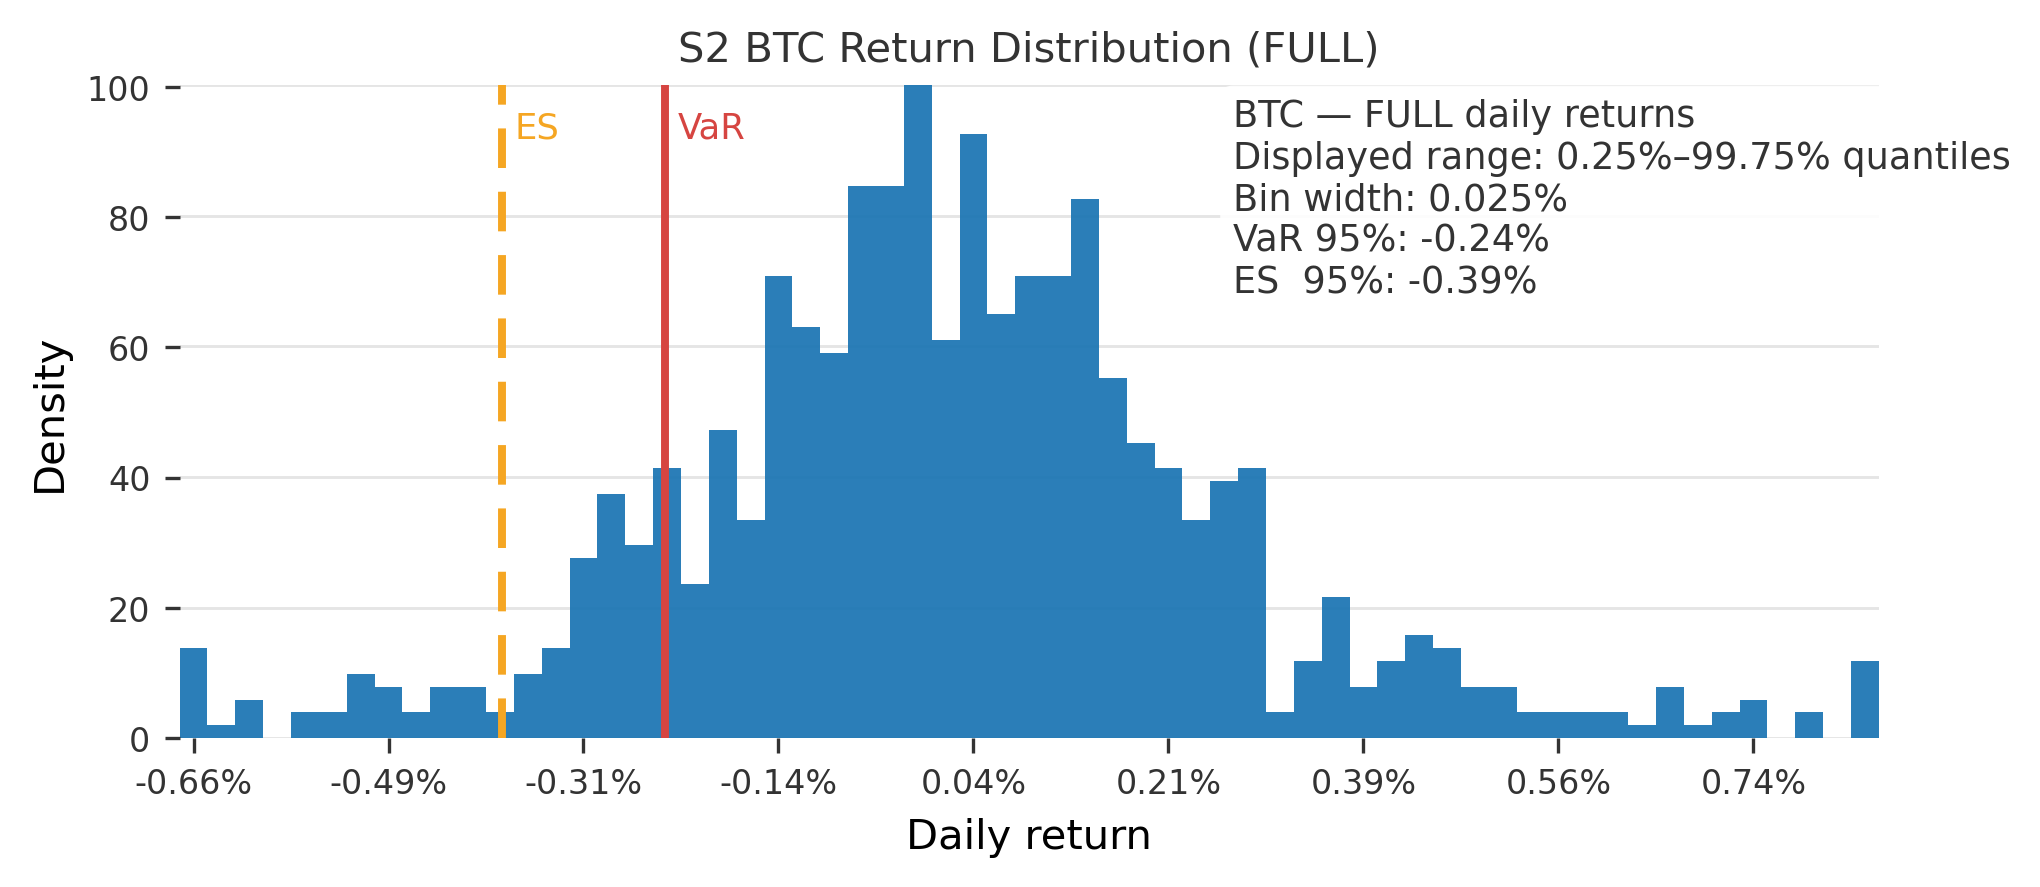

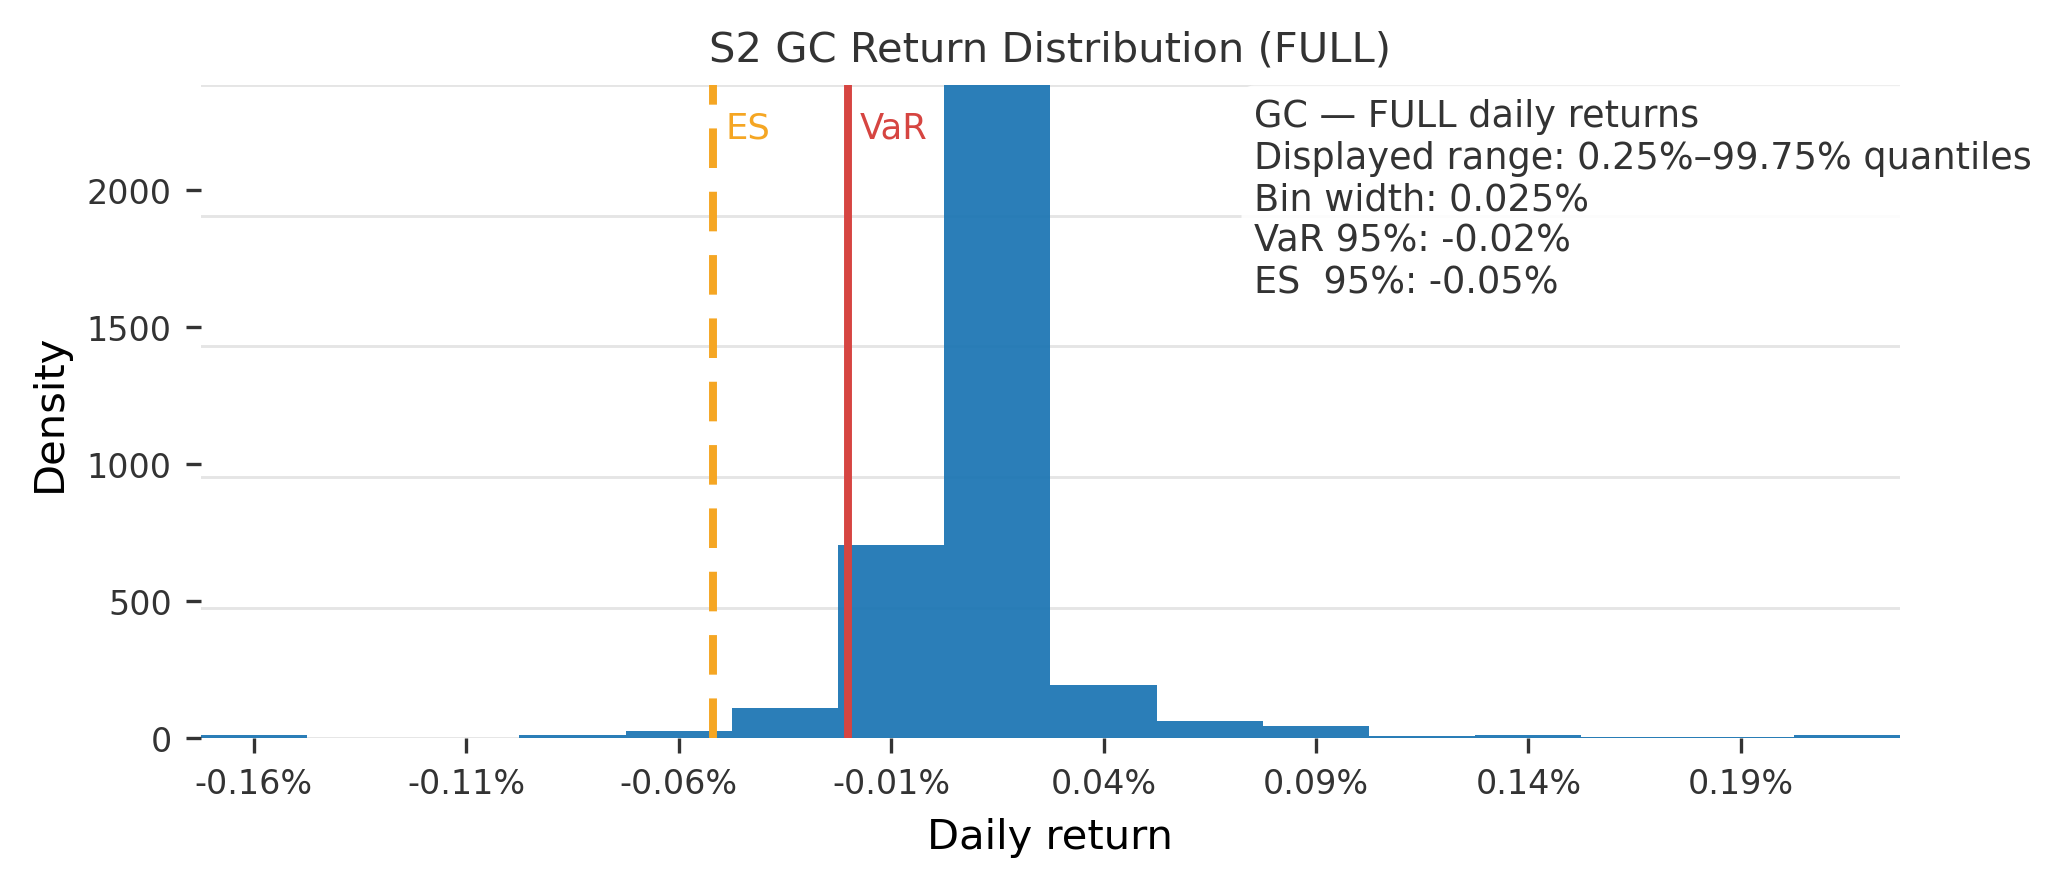

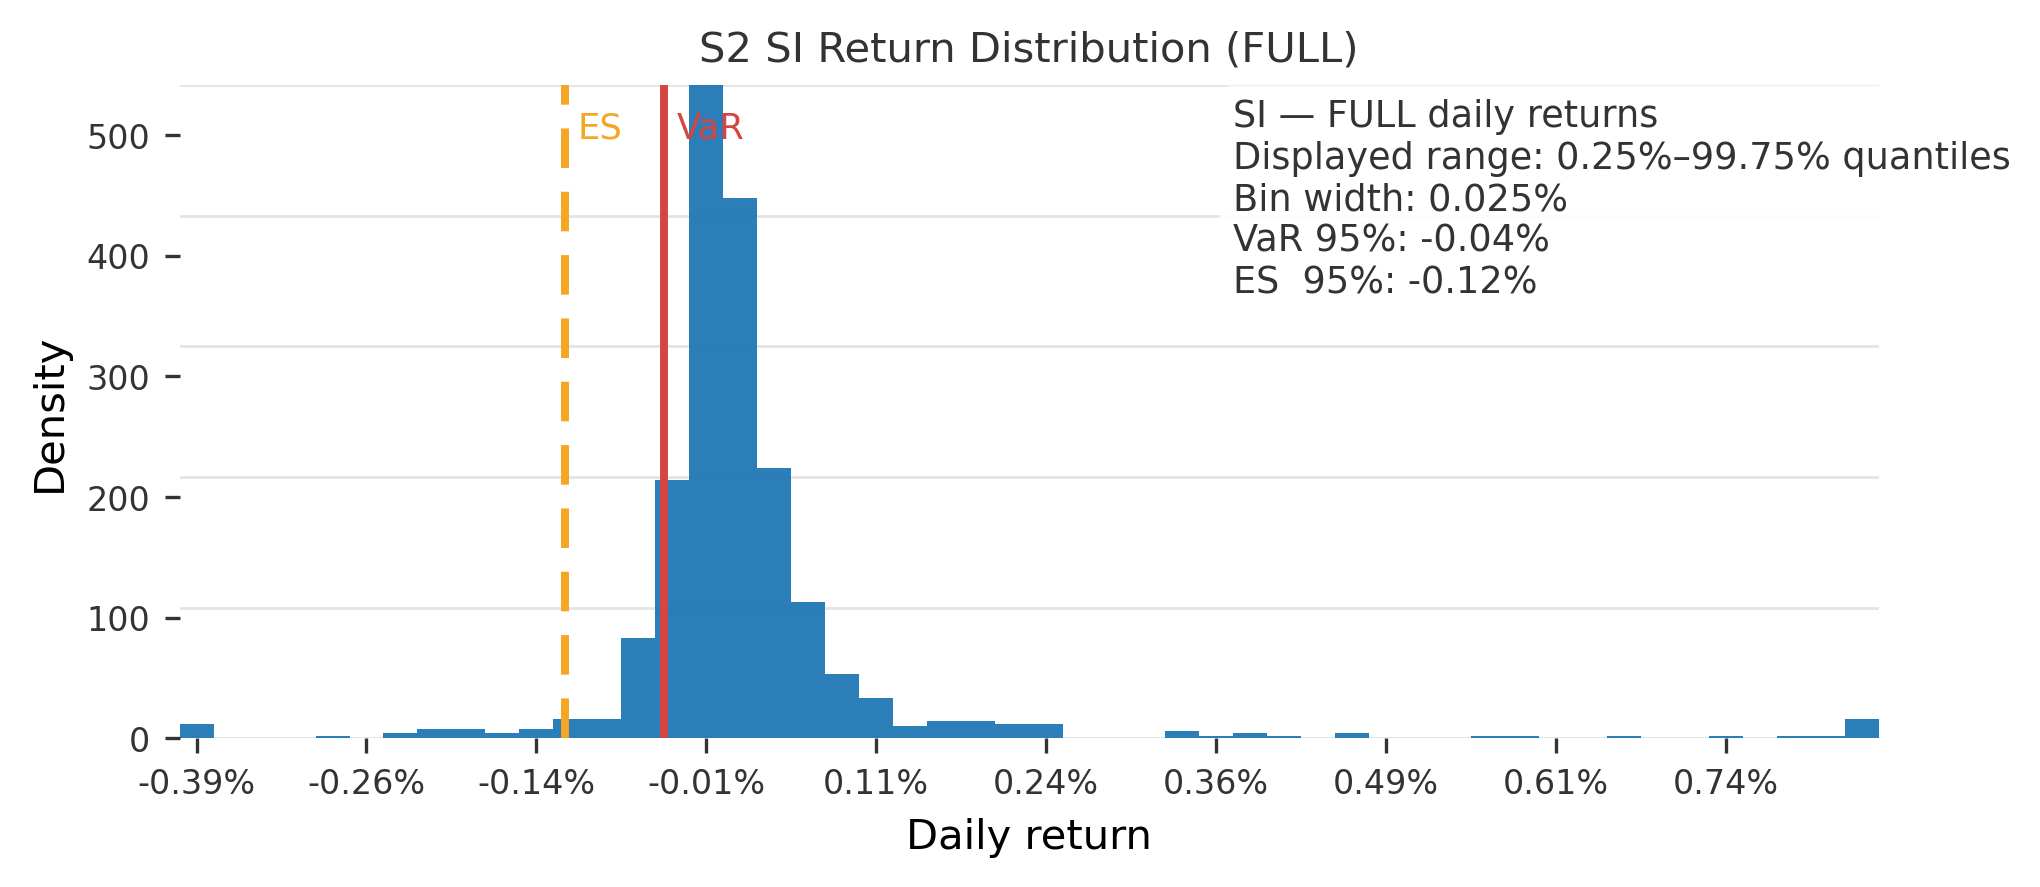

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANNUAL_DAYS = 252

def _is_oos_mask(idx: pd.DatetimeIndex, is_end: pd.Timestamp):
    is_mask  = idx <= is_end
    oos_mask = idx >  is_end
    return is_mask, oos_mask

def _var_es(rets: pd.Series, alpha: float = 0.05):
    r = rets.dropna().astype(float)
    if r.empty:
        return np.nan, np.nan
    var = float(np.quantile(r, alpha))
    tail = r[r <= var]
    es = float(tail.mean()) if len(tail) > 0 else var
    return var, es

def _winsor_clip(r: pd.Series, lo_q: float, hi_q: float) -> pd.Series:
    """Clip returns to [q_lo, q_hi] for nicer histograms (does NOT change VaR/ES calc)."""
    if r.empty:
        return r
    lo = float(np.quantile(r, lo_q))
    hi = float(np.quantile(r, hi_q))
    return r.clip(lower=lo, upper=hi)

def _format_pct(x: float) -> str:
    if not np.isfinite(x):
        return ""
    return f"{x*100:.2f}%"

def _x_to_axes_frac(x: float, left: float, right: float) -> float:
    """Map an x-value to axes fraction [0,1] given current x-limits."""
    if not np.isfinite(x) or right <= left:
        return 0.5
    return float((x - left) / (right - left))

def plot_return_distributions_var_es_granular(
    btc_res: dict, gc_res: dict, si_res: dict,
    is_end: str | pd.Timestamp = "2023-12-31",
    alpha: float = 0.05,
    period: str = "FULL",                    # "IS" | "OOS" | "FULL"

    view_clip=(0.0025, 0.9975),            
    bin_width=0.00025,                       
    density=True,
    ylim_cap_quantile=0.98,                  

    figsize=(6.4, 3.4),
    out_prefix="s2_ret_hist_granular",
):
    """
    Granular histogram per asset:
      - fixed bin width
      - display x-range clipped to central mass (quantile clip)
      - y-axis capped to avoid one spike dominating
      - VaR/ES computed on full (unclipped) returns
      - VaR/ES lines + labels use distinct colours
      - annotation block auto-placed to avoid overlapping VaR/ES markers
    """
    is_end = pd.Timestamp(is_end)

    assets = [
        ("BTC", btc_res, "#003B70"),
        ("GC",  gc_res,  "#4F81BD"),
        ("SI",  si_res,  "#A6A6A6"),
    ]

    DARK  = "#333333"
    LIGHT = "#E5E5E5"

    # distinct colours for risk markers, VaR (red-ish), ES  (amber)
    C_VAR = "#D64541"    
    C_ES  = "#F5A623"   

    for name, res, _asset_color in assets:
        d = res["daily"].copy()
        if d.empty or "equity" not in d.columns:
            print(f"[{name}] missing daily/equity, skipping.")
            continue

        eq = d["equity"].astype(float).dropna()
        rets = eq.pct_change().dropna()
        if rets.empty:
            print(f"[{name}] no returns, skipping.")
            continue

        is_mask, oos_mask = _is_oos_mask(rets.index, is_end)

        if period.upper() == "IS":
            r_full = rets.loc[is_mask].dropna()
            tag = "IS"
        elif period.upper() == "OOS":
            r_full = rets.loc[oos_mask].dropna()
            tag = "OOS"
        else:
            r_full = rets.dropna()
            tag = "FULL"

        if r_full.empty:
            print(f"[{name}] {tag} empty, skipping.")
            continue

        # risk metrics on FULL (unclipped) sample
        var, es = _var_es(r_full, alpha=alpha)

        # display series: clipped to central mass for nicer x-range
        lo_q, hi_q = view_clip
        r_view = _winsor_clip(r_full, lo_q, hi_q)

        x_min = float(r_view.min())
        x_max = float(r_view.max())
        left  = bin_width * np.floor(x_min / bin_width)
        right = bin_width * np.ceil(x_max / bin_width)
        if right <= left:
            right = left + bin_width

        bins = np.arange(left, right + 1e-12, bin_width)

        fig, ax = plt.subplots(figsize=figsize, dpi=300)

        counts, edges = np.histogram(r_view.values, bins=bins, density=density)
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths = np.diff(edges)

        ax.bar(centers, counts, width=widths, align="center", alpha=0.95)

        # VaR / ES lines (distinct colours)
        ax.axvline(var, color=C_VAR, linewidth=1.9, linestyle="-", zorder=5)
        ax.axvline(es,  color=C_ES,  linewidth=1.9, linestyle=(0, (5, 3)), zorder=5)

        ax.set_xlim(left, right)
        target_ticks = 10
        step = max(1, int(np.ceil(len(centers) / target_ticks)))
        xt = centers[::step]
        ax.set_xticks(xt)
        ax.set_xticklabels([f"{v*100:.2f}%" for v in xt])

        # y-axis cap to avoid remove extrens
        if len(counts) > 0 and np.isfinite(counts).all():
            cap = float(np.quantile(counts, ylim_cap_quantile))
            if cap > 0:
                ax.set_ylim(0, cap * 1.10)

        y0, y1 = ax.get_ylim()
        for y in np.linspace(y0, y1, 6):
            ax.axhline(y, color=LIGHT, linewidth=0.7, zorder=0)

        y_top = ax.get_ylim()[1]
        ax.annotate("VaR", xy=(var, y_top), xytext=(3, -6), textcoords="offset points",
                    ha="left", va="top", fontsize=8.5, color=C_VAR, zorder=6)
        ax.annotate("ES",  xy=(es,  y_top), xytext=(3, -6), textcoords="offset points",
                    ha="left", va="top", fontsize=8.5, color=C_ES, zorder=6)

        var_f = _x_to_axes_frac(var, left, right)
        es_f  = _x_to_axes_frac(es,  left, right)
        m_f   = np.nanmean([var_f, es_f])
        text_x = 0.62 if m_f < 0.50 else 0.02

        txt = (
            f"{name} — {tag} daily returns\n"
            f"Displayed range: {lo_q:.2%}–{hi_q:.2%} quantiles\n"
            f"Bin width: {bin_width*100:.3f}%\n"
            f"VaR {int((1-alpha)*100)}%: {_format_pct(var)}\n"
            f"ES  {int((1-alpha)*100)}%: {_format_pct(es)}"
        )
        ax.text(
            text_x, 0.98, txt, transform=ax.transAxes,
            ha="left", va="top", fontsize=8.8, color=DARK, zorder=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="none", alpha=0.92)
        )

        ax.set_title(f"S2 {name} Return Distribution ({tag})", fontsize=10, color=DARK, pad=6)
        ax.set_xlabel("Daily return")
        ax.set_ylabel("Density" if density else "Count")
        ax.tick_params(axis="both", colors=DARK, labelsize=8)
        for spine in ax.spines.values():
            spine.set_visible(False)

        fig.subplots_adjust(left=0.10, right=0.985, top=0.86, bottom=0.22)

 
        plt.show()


# Calls - note - we can use the IS or OOS if wanted
plot_return_distributions_var_es_granular(btc_res, gc_res, si_res, period="FULL")
# plot_return_distributions_var_es_granular(btc_res, gc_res, si_res, period="IS")
# plot_return_distributions_var_es_granular(btc_res, gc_res, si_res, period="OOS")


/var/folders/tl/hb3sh0p16wb8f6cdsnkjq_wm0000gn/T/ipykernel_89517/2301224224.py:67: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  bench_rets = bench_px.pct_change().dropna(how="all")



=== S2 vs major asset classes — correlation (daily returns), 2018–2025 ===
        Gold (GLD)  Credit (HYG)  US Eq (QQQ)  US Eq (SPY)  US Rates (TLT)  Oil (USO)  USD (UUP)  Real Estate (VNQ)  VIX (^VIX)
S2 BTC      -0.019         0.028        0.045        0.035          -0.021      0.016      0.036             -0.009      -0.035
S2 GC       -0.021        -0.057       -0.041       -0.055           0.017     -0.045      0.007             -0.039       0.011
S2 SI       -0.028         0.106       -0.012       -0.013           0.036     -0.068     -0.028              0.017      -0.009


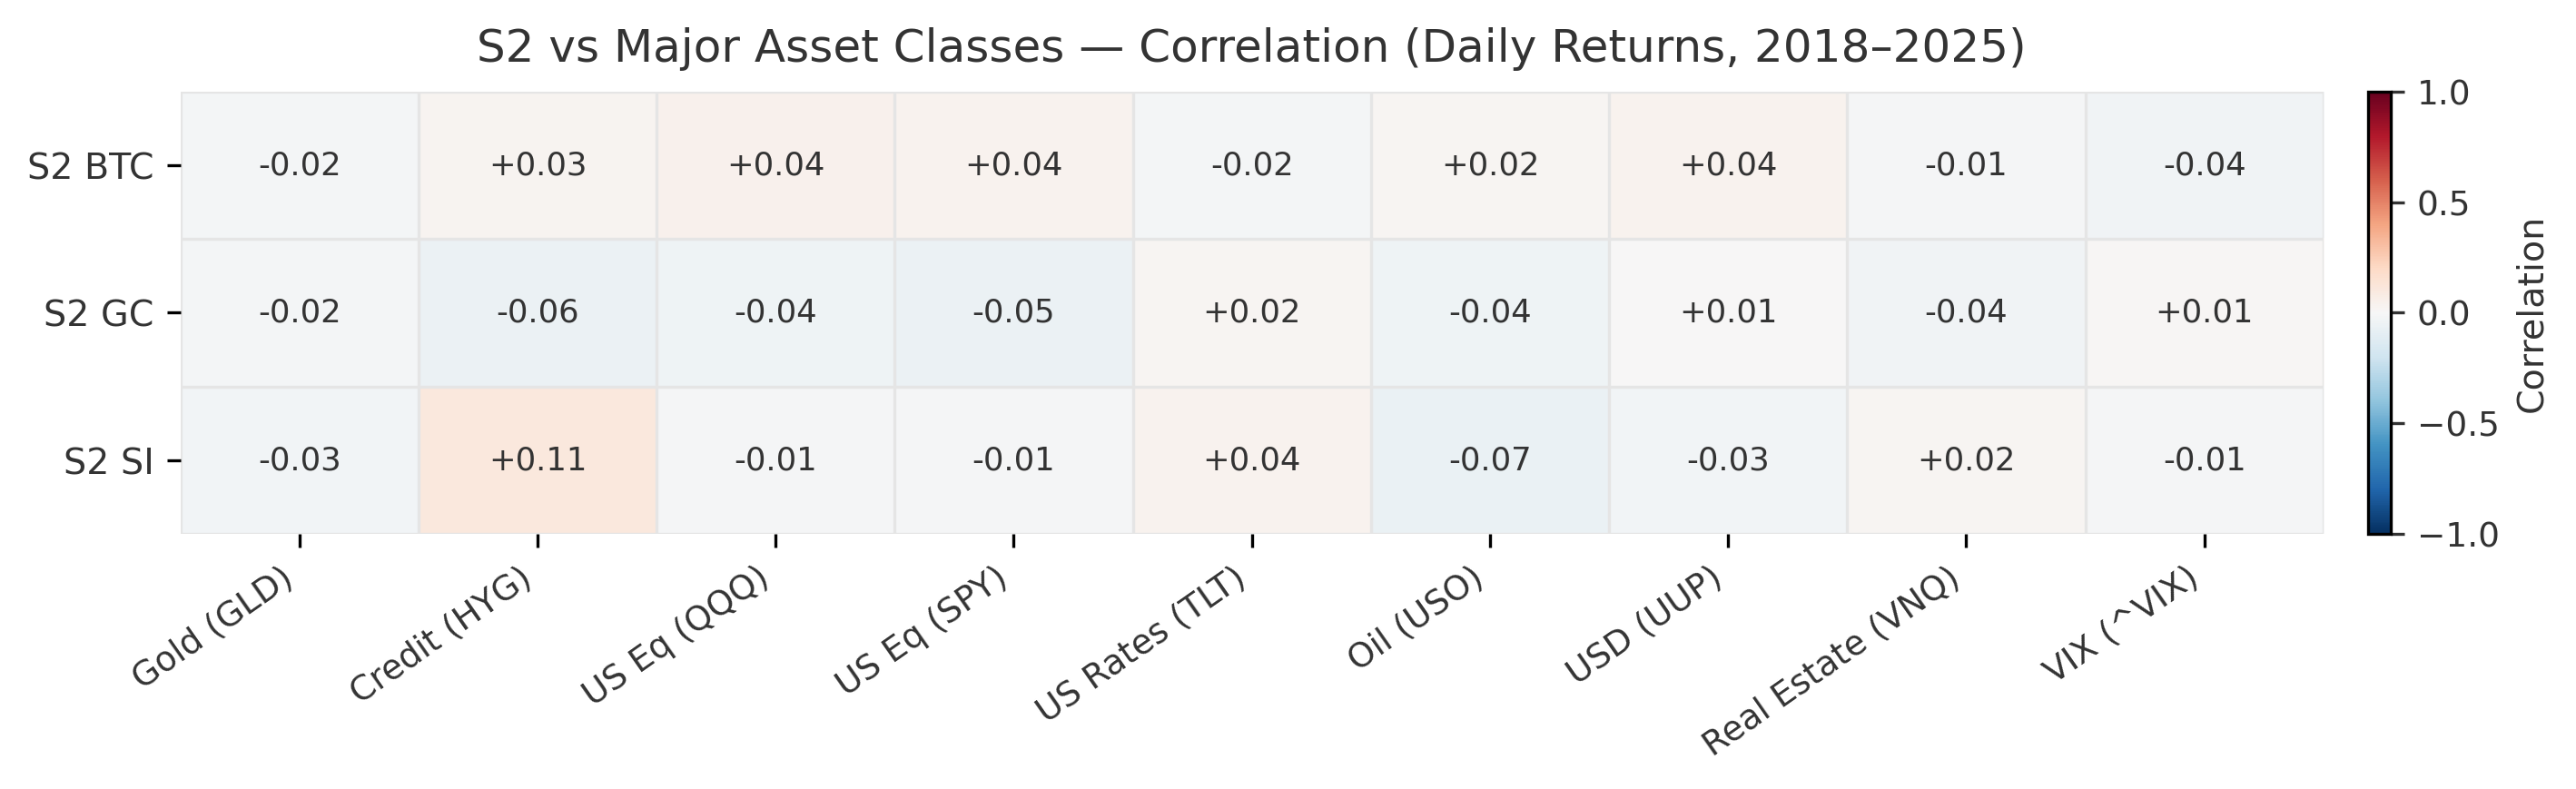

(<Figure size 2940x870 with 2 Axes>,
 <Axes: title={'center': 'S2 vs Major Asset Classes — Correlation (Daily Returns, 2018–2025)'}>)

In [18]:
# S2 correl matrix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError as e:
    raise ImportError("yfinance not installed. Run: pip install yfinance") from e

DARK  = "#333333"
LIGHT = "#E5E5E5"
C_BTC = "#003B70"

def _eq_to_rets(eq: pd.Series) -> pd.Series:
    eq = eq.dropna().astype(float).sort_index()
    return eq.pct_change().dropna()

def _yf_download_prices(
    tickers: dict[str, str],   # {"nice name": "YF_TICKER", ...}
    start: str,
    end: str,
) -> pd.DataFrame:
    tk = list(tickers.values())
    raw = yf.download(
        tickers=tk,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=True,
        actions=False,
        progress=False,
        threads=True,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        field = "Adj Close" if ("Adj Close" in raw.columns.get_level_values(0)) else "Close"
        px = raw[field].copy()
    else:
        px = raw.copy()

    inv = {v: k for k, v in tickers.items()}
    px = px.rename(columns=inv)

    px.index = pd.to_datetime(px.index)
    px = px.sort_index()
    px = px.dropna(axis=1, how="all")
    return px

def corr_matrix_s2_vs_benchmarks_full(
    s2_eq_map: dict[str, pd.Series],   # {"BTC": eq, "GC": eq, "SI": eq}
    bench_px: pd.DataFrame,
    start: str,
    end: str,
) -> pd.DataFrame:
    s2_rets = {}
    for k, eq in s2_eq_map.items():
        if eq is None or eq.dropna().empty:
            continue
        s2_rets[f"S2 {k}"] = _eq_to_rets(eq)

    s2_rets = pd.concat(s2_rets, axis=1).dropna(how="all")
    if s2_rets.empty:
        raise ValueError("No S2 returns available.")

    bench_rets = bench_px.pct_change().dropna(how="all")

    t0 = pd.Timestamp(start)
    t1 = pd.Timestamp(end)
    s2_rets = s2_rets.loc[(s2_rets.index >= t0) & (s2_rets.index <= t1)]
    bench_rets = bench_rets.loc[(bench_rets.index >= t0) & (bench_rets.index <= t1)]

    df = pd.concat([s2_rets, bench_rets], axis=1).dropna()
    if df.empty:
        raise ValueError("No overlapping dates after aligning S2 returns with benchmark returns.")

    strat_cols = list(s2_rets.columns)
    bench_cols = list(bench_rets.columns)

    out = pd.DataFrame(index=strat_cols, columns=bench_cols, dtype=float)
    for s in strat_cols:
        for b in bench_cols:
            out.loc[s, b] = df[s].corr(df[b])
    return out

def plot_corr_heatmap(
    corr: pd.DataFrame,
    title: str = "S2 vs Major Asset Classes — Correlation (Daily Returns)",
    out_png: str | None = "s2_corr_heatmap_2018_2025.png",
    out_pdf: str | None = "s2_corr_heatmap_2018_2025.pdf",
    figsize=(9.8, 2.9),
):
    mat = corr.astype(float)

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    im = ax.imshow(mat.values, vmin=-1, vmax=1, aspect="auto", cmap="RdBu_r")

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_xticklabels(mat.columns.tolist(), rotation=35, ha="right", fontsize=9, color=DARK)
    ax.set_yticklabels(mat.index.tolist(), fontsize=9.5, color=DARK)

    ax.set_title(title, fontsize=12, color=DARK, pad=8)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8.5, color=DARK)

    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color=LIGHT, linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02)
    cbar.ax.tick_params(labelsize=9, colors=DARK)
    cbar.set_label("Correlation", fontsize=9.5, color=DARK)

    fig.subplots_adjust(left=0.14, right=0.985, top=0.84, bottom=0.28)

    if out_png:
        fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    if out_pdf:
        fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    return fig, ax

def plot_rolling_corr_s2(
    s2_eq: pd.Series,
    bench_prices: pd.Series | None = None,
    bench_rets: pd.Series | None = None,
    window: int = 126,
    title: str = "S2 Rolling correlation (6M)",
    out_png: str | None = "s2_rolling_corr.png",
    out_pdf: str | None = "s2_rolling_corr.pdf",
):
    r_s = _eq_to_rets(s2_eq)

    if bench_rets is None:
        if bench_prices is None:
            raise ValueError("Provide bench_prices or bench_rets.")
        r_b = bench_prices.dropna().astype(float).sort_index().pct_change().dropna()
    else:
        r_b = bench_rets.dropna().astype(float).sort_index()

    df = pd.concat([r_s.rename("strategy"), r_b.rename("bench")], axis=1).dropna()
    if df.empty:
        raise ValueError("No overlap for rolling correlation.")

    minp = max(20, window // 5)
    roll = df["strategy"].rolling(window, min_periods=minp).corr(df["bench"])

    fig, ax = plt.subplots(figsize=(8.6, 3.2), dpi=300)
    ax.plot(roll.index, roll.values, color=C_BTC, linewidth=1.9)
    ax.axhline(0, color=LIGHT, linestyle="--", linewidth=1.0)

    y0, y1 = ax.get_ylim()
    for y in np.linspace(y0, y1, 6):
        ax.axhline(y, color=LIGHT, linewidth=0.7, zorder=0)

    ax.set_title(title, fontsize=11, color=DARK, pad=6)
    ax.set_ylabel("Corr")
    ax.tick_params(axis="both", colors=DARK, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.86, bottom=0.18)
    if out_png: fig.savefig(out_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    if out_pdf: fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    return roll


s2_eq_map = {
    "BTC": btc_res["daily"]["equity"],
    "GC":  gc_res["daily"]["equity"],
    "SI":  si_res["daily"]["equity"],
}

bench_tickers = {
    "US Eq (SPY)": "SPY",
    "US Eq (QQQ)": "QQQ",
    "US Rates (TLT)": "TLT",
    "Credit (HYG)": "HYG",
    "Gold (GLD)": "GLD",
    "Oil (USO)": "USO",
    "USD (UUP)": "UUP",
    "Real Estate (VNQ)": "VNQ",
    "VIX (^VIX)": "^VIX",
}

START = "2018-01-01"
END   = "2025-12-31"

bench_prices = _yf_download_prices(bench_tickers, start=START, end=END)

corr_full_s2 = corr_matrix_s2_vs_benchmarks_full(
    s2_eq_map=s2_eq_map,
    bench_px=bench_prices,
    start=START,
    end=END,
)

print("\n=== S2 vs major asset classes — correlation (daily returns), 2018–2025 ===")
print(corr_full_s2.round(3).to_string())

plot_corr_heatmap(
    corr_full_s2,
    title="S2 vs Major Asset Classes — Correlation (Daily Returns, 2018–2025)",
    out_png="s2_corr_heatmap_2018_2025.png",
    out_pdf="s2_corr_heatmap_2018_2025.pdf",
    figsize=(9.8, 2.9),
)

